## Preliminaries

In [1]:
# pip install pandas matplotlib seaborn odfpy statsmodels

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import statsmodels.formula.api as smf
from scipy.stats import kendalltau, spearmanr

from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.model_selection import LeaveOneOut, cross_val_predict

## Workload and Results Loading

In [3]:
pm100 = pd.read_csv('workloads/pm100/pm100.swf', header=None, sep='\t')

In [4]:
def load_results(path):
    """
    Load results from CSV or ODS file.
    Assumes decimals use '.' and columns are:
    workload, Policy, Estimation, AWT, ASD, ASU
    """
    if path.endswith(".csv"):
        df = pd.read_csv(path)
    elif path.endswith(".ods"):
        df = pd.read_excel(path, engine="odf")
    else:
        raise ValueError("Unsupported file format")

    # Ensure numeric columns are floats
    numeric_cols = ["AWT", "ASD"]
    df[numeric_cols] = df[numeric_cols].astype(float)

    return df


In [5]:
df = load_results('results/pm100_results.ods')
df = df[df["Workload"] == "Normal"]

In [6]:
df

,Workload,Policy,Estimation,AWT,ASD,ASU
0,Normal,1 - SJF,1 - User,314.56,3.39,41.438490
1,Normal,1 - SJF,2 - Actual,297.49,1.46,41.438490
2,Normal,1 - SJF,3 - Heuristic,334.88,2.58,41.438490
3,Normal,1 - SJF,4 - DT,323.70,2.42,41.438490
4,Normal,1 - SJF,5 - RNP,321.21,2.40,41.438490
5,Normal,1 - SJF,6 - KNN,326.67,3.38,41.438490
6,Normal,1 - SJF,7 - LLM,325.20,2.09,41.438490
7,Normal,2 - EASYBF,1 - User,312.48,2.66,41.438491
8,Normal,2 - EASYBF,2 - Actual,312.48,2.66,41.438491
9,Normal,2 - EASYBF,3 - Heuristic,312.48,2.66,41.438491


## Averages Computation

### Policies Averages

In [7]:
def avg_by_Policy(df):
    return (
        df
        .groupby(["Policy"], as_index=False)
        .agg({
            "AWT": "mean",
            "ASD": "mean",
            "ASU": "mean"
        })
        .rename(columns={
            "AWT": "awt_avg",
            "ASD": "asd_avg",
            "ASU": "asu_avg"
        })
    )


In [8]:
avg_p = avg_by_Policy(df)
avg_p

,Policy,awt_avg,asd_avg,asu_avg
0,1 - SJF,320.530000,2.531429,41.438490
1,2 - EASYBF,312.308571,2.655714,41.438491
2,3 - PRB-JA,307.038571,2.581429,41.438491
3,4 - PRB-JR,307.038571,2.581429,41.438491


### Estimations Averages

In [9]:
def avg_by_Estimation(df):
    return (
        df
        .groupby(["Estimation"], as_index=False)
        .agg({
            "AWT": "mean",
            "ASD": "mean",
            "ASU": "mean"
        })
        .rename(columns={
            "AWT": "awt_avg",
            "ASD": "asd_avg",
            "ASU": "asu_avg"
        })
    )


In [10]:
avg_e = avg_by_Estimation(df)
avg_e

,Estimation,awt_avg,asd_avg,asu_avg
0,1 - User,312.0750,2.8275,41.438491
1,2 - Actual,294.6925,2.0650,41.438491
2,3 - Heuristic,317.5350,2.6600,41.438491
3,4 - DT,314.6325,2.6050,41.438491
4,5 - RNP,313.4150,2.5875,41.438491
5,6 - KNN,314.7675,2.8500,41.438491
6,7 - LLM,314.9850,2.5175,41.438491


## Bar Plots

### Helpers

In [11]:
def plot_metrics(df, policy_name="SJF", image_path=""):

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    # metrics = ['AWT', 'ASD', 'ASU']
    metrics = ['AWT', 'ASD']
    
    
    for i, metric in enumerate(metrics):
        ax = axes[i]
        metric_col = f"{metric}"
        
        # Calcolo soglia per il posizionamento del testo (20% del massimo)
        max_val = df[metric_col].max()
        threshold = max_val * 0.20

        # Soglia per l'orientamento del testo (vertical vs horizontal)
        orientation_threshold = 0
        
        # Normalizzazione per la colormap
        norm = plt.Normalize(df[metric_col].min(), df[metric_col].max())
        colors = plt.cm.RdYlGn_r(norm(df[metric_col]))

        # Creazione barre
        bars = ax.bar(df['Estimation'], df[metric_col], color=colors, alpha=0.8)

        # Aggiunta valori (Logica per centro barra e rotazione verticale)
        for bar in bars:
            yval = bar.get_height()
            
            # Determiniamo se il valore deve essere verticale (> 1000)
            rotation = 'vertical' if yval > orientation_threshold else 'horizontal'
            
            if yval < threshold:
                # Sopra la barra
                y_pos = yval + (max_val * 0.02)
                va_pos = 'bottom'
            else:
                # Al centro della barra
                y_pos = yval / 2
                va_pos = 'center'

            ax.text(
                bar.get_x() + bar.get_width()/2, 
                y_pos, 
                round(yval, 4), 
                ha='center', 
                va=va_pos, 
                rotation=rotation, # Applica rotazione verticale se > 1000
                color='black'
            )

        ax.set_title(f'{policy_name} - {metric.upper()}', fontsize=14)
        ax.set_ylabel(metric.upper())
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        
        # Ruota le etichette X a 45 gradi per ogni subplot
        ax.tick_params(axis='x', labelrotation=45)

    plt.tight_layout()

    # Salvataggio opzionale
    if image_path:
        plt.savefig(image_path, dpi=300)
        print(f"Grafico salvato in: {image_path}")

    plt.show()

def plot_metrics_horizontal(df, policy_name="SJF", max_values=None, image_path=""):
    """
    max_values: dict opzionale, es: {'AWT': 5000, 'ASD': 200, 'ASU': 1}
    """
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    # metrics = ['AWT', 'ASD', 'ASU']
    metrics = ['AWT', 'ASD']
    
    for i, metric in enumerate(metrics):
        ax = axes[i]
        metric_col = f"{metric}"
        
        # 1. Gestione della scala fissa
        # Se max_values è fornito, usiamo quello, altrimenti usiamo il max del dataframe corrente
        current_max = df[metric_col].max()
        limit_val = max_values[metric] if (max_values and metric in max_values) else current_max
        
        # Soglia per il testo basata sul limite dell'asse (per coerenza visiva)
        threshold = limit_val * 0.20
        
        # Normalizzazione colori (sempre basata sui dati reali del DF)
        norm = plt.Normalize(df[metric_col].min(), df[metric_col].max())
        colors = plt.cm.RdYlGn_r(norm(df[metric_col]))

        # Creazione barre orizzontali
        bars = ax.barh(df['Estimation'], df[metric_col], color=colors, alpha=0.8)

        # 2. Impostazione del limite dell'asse X
        ax.set_xlim(0, limit_val)

        # Aggiunta valori numerici
        for bar in bars:
            xval = bar.get_width()
            
            # Se il valore eccede il limite (per errore), lo clip-piamo per il posizionamento
            display_x = min(xval, limit_val)
            
            if xval < threshold:
                x_pos = display_x + (limit_val * 0.02)
                ha_pos = 'left'
            else:
                x_pos = display_x / 2
                ha_pos = 'center'

            ax.text(
                x_pos, 
                bar.get_y() + bar.get_height()/2, 
                round(xval, 4), 
                ha=ha_pos, 
                va='center', 
                color='black',
                fontsize=11
            )

        ax.set_title(f'{metric.upper()}', fontsize=20, pad=20)
        ax.tick_params(axis='y', labelsize=14)
        ax.tick_params(axis='x', labelsize=14)
        
        ax.grid(axis='x', linestyle='--', alpha=0.4)
        
    plt.tight_layout()

    if image_path:
        plt.savefig(image_path, dpi=300, bbox_inches='tight')
        print(f"Grafico salvato in: {image_path}")

    plt.show()

### Plots

Grafico salvato in: images/66000x980/bar_plot_sjf_M1.png


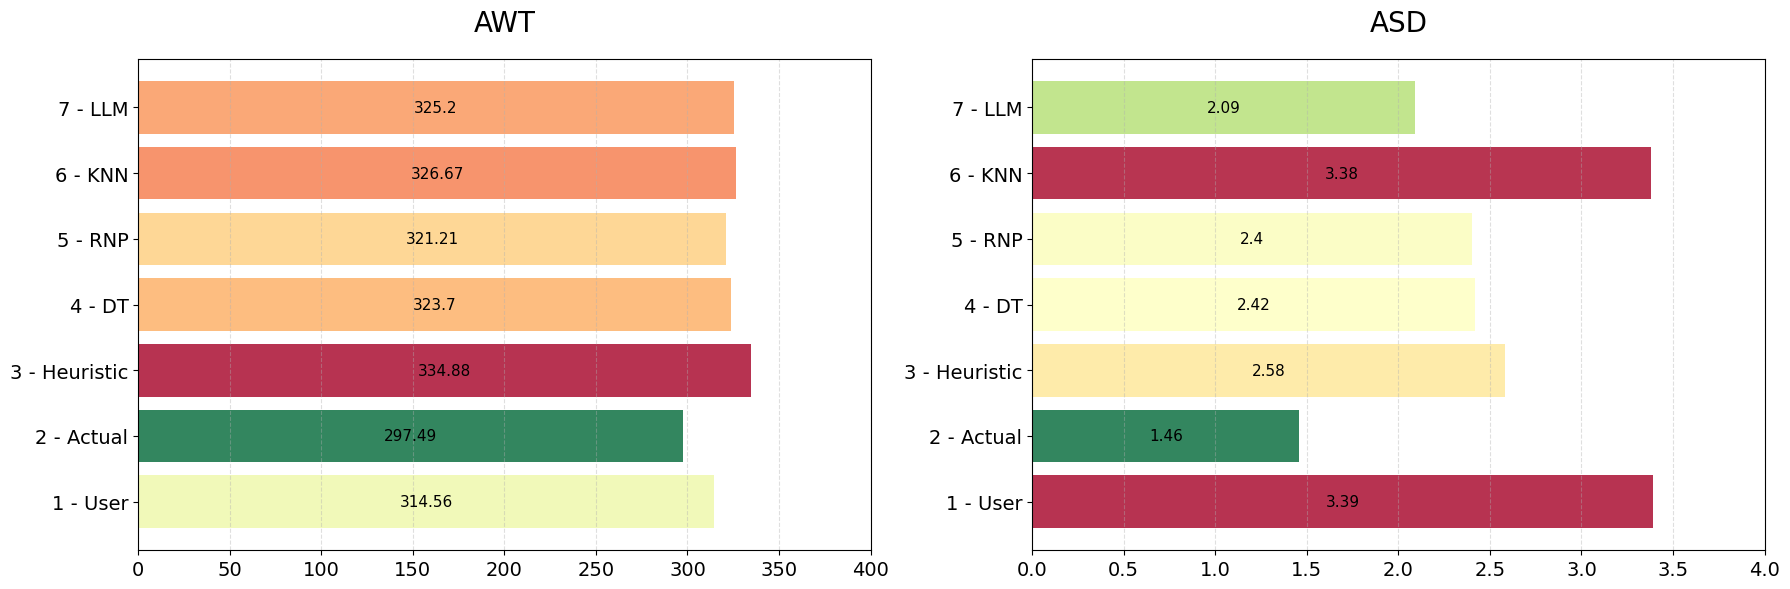

In [12]:
plot_metrics_horizontal(df[0:7], policy_name="SJF", max_values={'AWT': 400, 'ASD': 4, 'ASU': 100}, image_path="images/66000x980/bar_plot_sjf_M1.png")

Grafico salvato in: images/66000x980/bar_plot_easy_M1.png


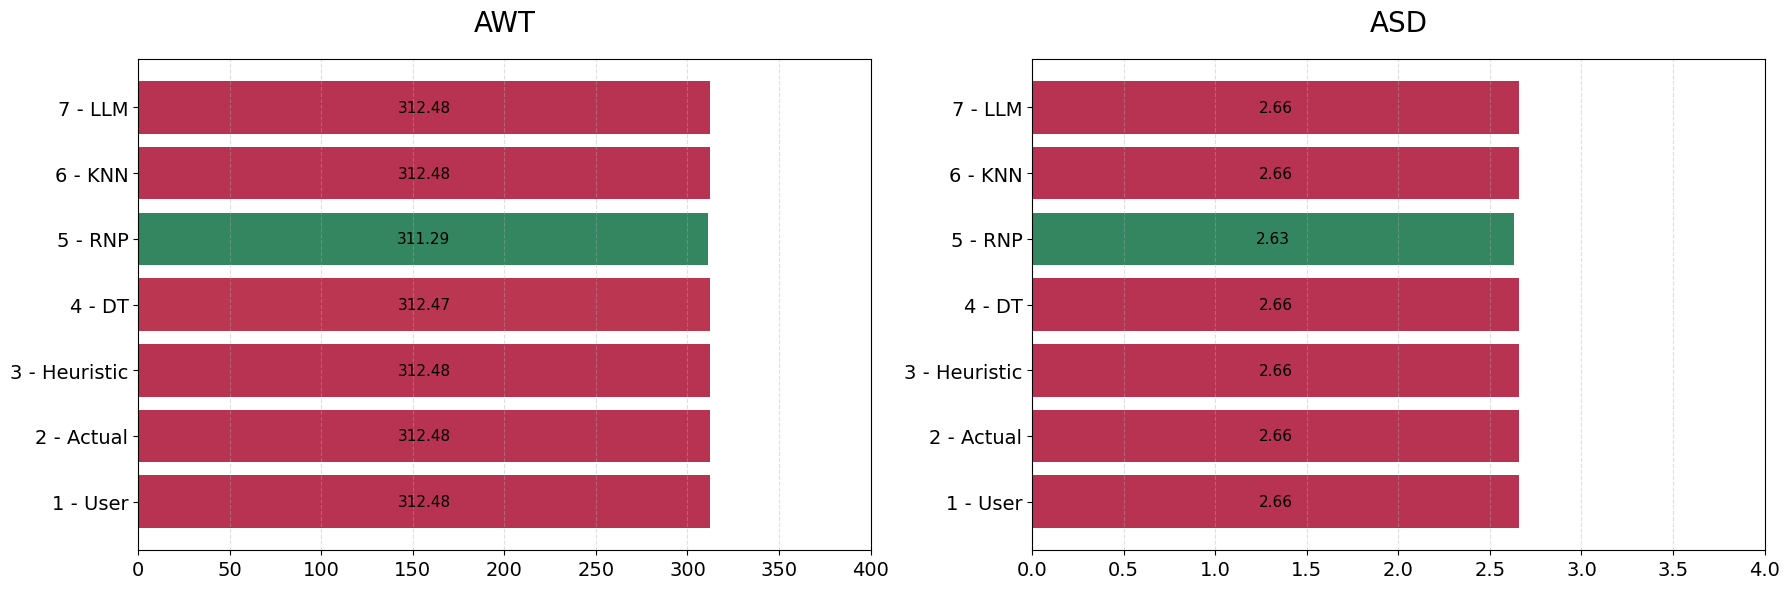

In [13]:
plot_metrics_horizontal(df[7:14], policy_name="EASYBF", max_values={'AWT': 400, 'ASD': 4, 'ASU': 100}, image_path="images/66000x980/bar_plot_easy_M1.png")

Grafico salvato in: images/66000x980/bar_plot_prb_M1.png


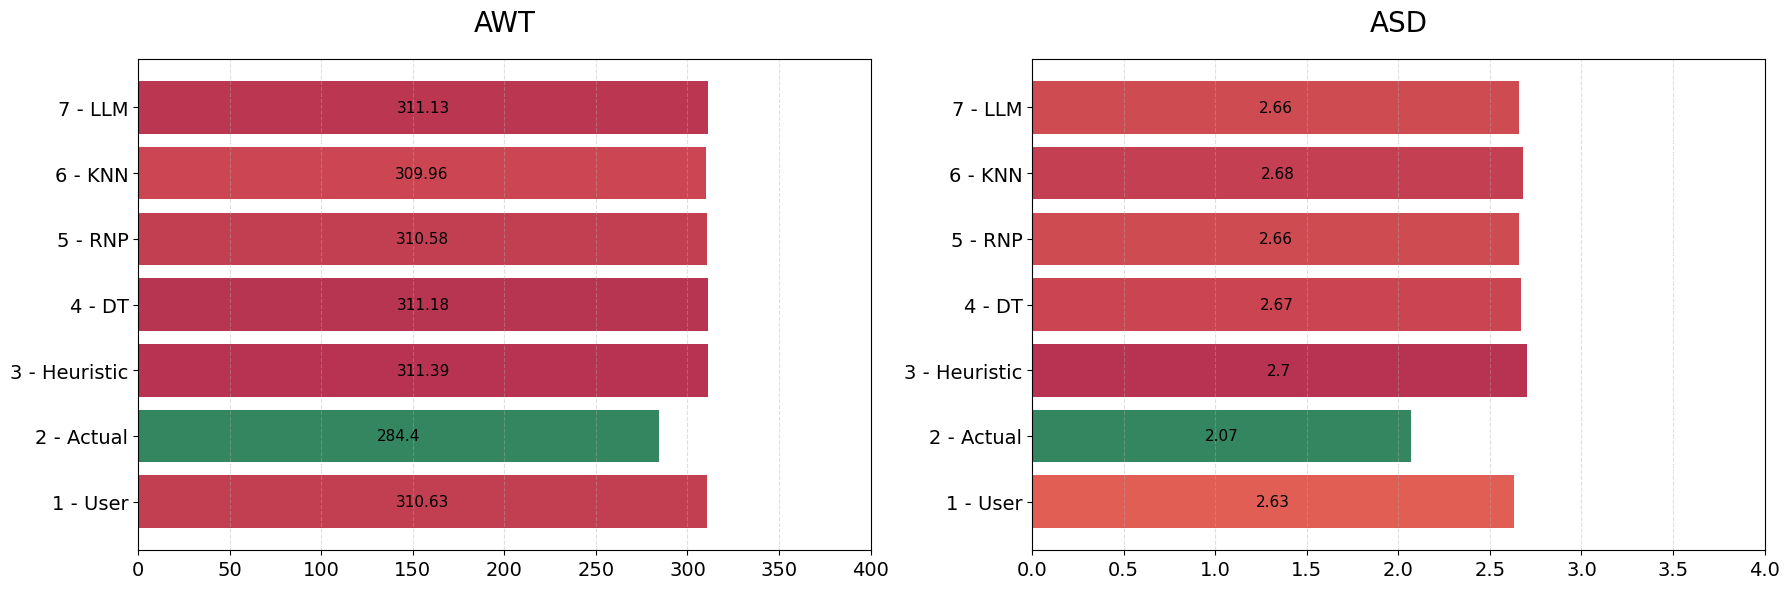

In [14]:
plot_metrics_horizontal(df[14:21], policy_name="PRB-JA", max_values={'AWT': 400, 'ASD': 4, 'ASU': 100}, image_path="images/66000x980/bar_plot_prb_M1.png")

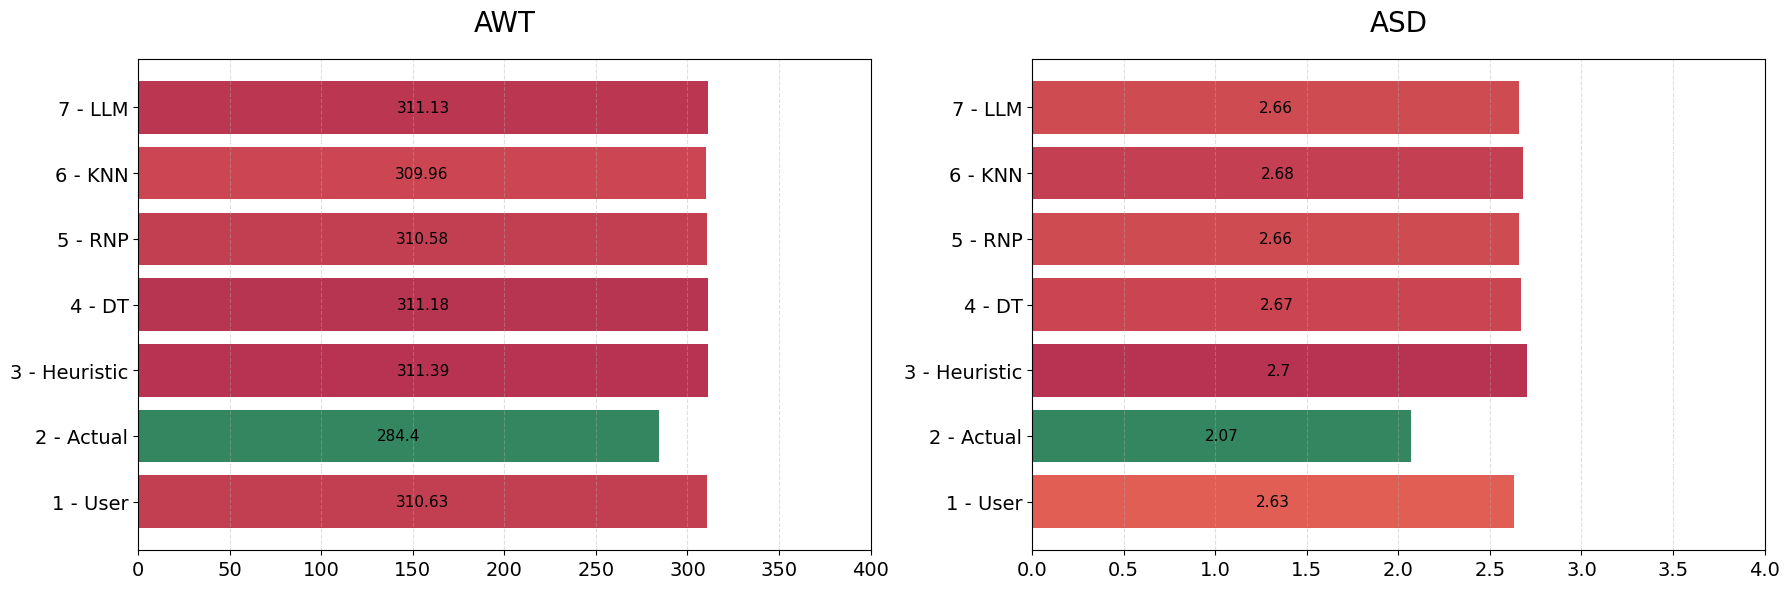

In [15]:
plot_metrics_horizontal(df[21:28], policy_name="PRB-JR", max_values={'AWT': 400, 'ASD': 4, 'ASU': 100})

## Heatmaps

In [16]:
def heatmap_avg_across_workloads(avg_df, metric, approx=".2f", image_path=""):
    pivot = avg_df.pivot(
        index="Policy",
        columns="Estimation",
        values=f"{metric}"
    )

    plt.figure(figsize=(8, 4))
    sns.heatmap(pivot, annot=True, fmt=approx, cmap="RdYlGn_r", cbar=False)
    plt.title(f"{metric.upper()}")
    plt.xticks(rotation = 45)
    plt.yticks(rotation = 45)
    plt.tight_layout()

    # Salvataggio opzionale
    if image_path:
        plt.savefig(image_path, dpi=300)
        print(f"Grafico salvato in: {image_path}")

    plt.show()

Grafico salvato in: images/66000x980/heatmap_awt_M1.png


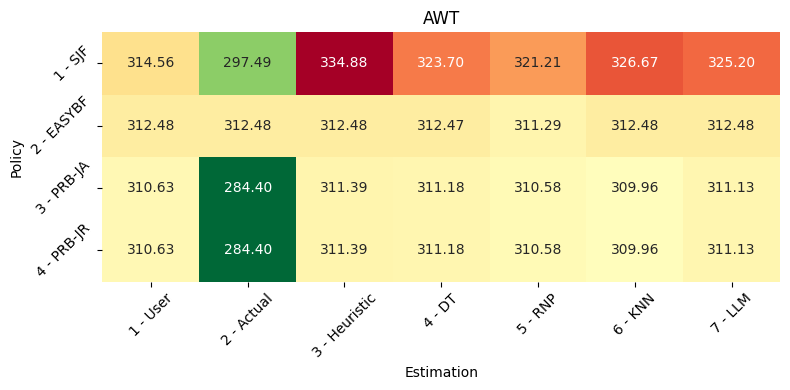

In [17]:
heatmap_avg_across_workloads(df, "AWT", image_path="images/66000x980/heatmap_awt_M1.png")

Grafico salvato in: images/66000x980/heatmap_asd_M1.png


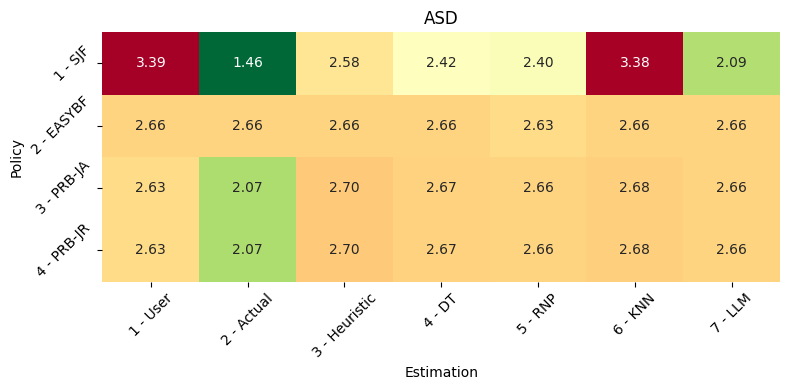

In [18]:
heatmap_avg_across_workloads(df, "ASD", image_path="images/66000x980/heatmap_asd_M1.png")

In [19]:
# heatmap_avg_across_workloads(df, "ASU", approx=".4f", image_path="images/66000x980/heatmap_asu_M1.png")

## Estimation Accuracy vs Scheduling Metrics

### Metrics Loading

In [20]:
acc_df = pd.read_csv("results/pm100_metrics.csv")

# Keep only workloads used in scheduling
acc_df = acc_df[acc_df["Workload"] == "Normal"]

In [21]:
acc_df

,Workload,Estimation,Average Error,MAE,MAPE,EA,TAU,MAE_OVER,MAE_UNDER,%_OVER,%_UNDER,%_EXACT,MAE_A,MAE_B,MAE_C,MAE_D
0,Normal,1 - User,15:40:16,56416.198364,2999.341407,0.107134,-0.441967,56416.198364,0.000000,1.000000,0.000000,0.000000,66992.699852,25339.566412,58617.308039,35295.568528
1,Normal,2 - Actual,00:00:00,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
2,Normal,3 - Heuristic,01:01:35,3695.931497,53.277426,0.248127,0.320968,2096.918202,8785.644558,0.758539,0.239634,0.001828,1782.750845,9371.084486,1049.400643,20768.548223
3,Normal,4 - DT,00:56:07,3367.512313,3.901901,0.578268,0.669683,3262.773433,5234.749602,0.427512,0.376835,0.195653,1001.674190,10288.942140,1588.455305,20762.949239
4,Normal,5 - RNP,01:15:06,4506.397537,12.230835,0.562610,0.549939,7738.087200,4337.123422,0.361615,0.393852,0.244532,2034.655000,11502.112263,3950.100322,32114.309645
5,Normal,6 - KNN,00:59:17,3557.569267,96.500035,0.275680,0.226877,3009.026295,5871.905144,0.799853,0.195982,0.004164,2619.284380,6152.703239,3733.145338,16046.096447
6,Normal,7 - LLM,00:06:34,394.735919,1.621773,0.686491,0.747376,499.482402,1827.214101,0.409431,0.104110,0.486458,143.982006,1140.682557,93.766559,2092.279188


In [22]:
summary_df = df.merge(
    acc_df,
    on=["Workload", "Estimation"],
    how="left"
)

In [23]:
summary_df

,Workload,Policy,Estimation,AWT,ASD,ASU,Average Error,MAE,MAPE,EA,TAU,MAE_OVER,MAE_UNDER,%_OVER,%_UNDER,%_EXACT,MAE_A,MAE_B,MAE_C,MAE_D
0,Normal,1 - SJF,1 - User,314.56,3.39,41.438490,15:40:16,56416.198364,2999.341407,0.107134,-0.441967,56416.198364,0.000000,1.000000,0.000000,0.000000,66992.699852,25339.566412,58617.308039,35295.568528
1,Normal,1 - SJF,2 - Actual,297.49,1.46,41.438490,00:00:00,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
2,Normal,1 - SJF,3 - Heuristic,334.88,2.58,41.438490,01:01:35,3695.931497,53.277426,0.248127,0.320968,2096.918202,8785.644558,0.758539,0.239634,0.001828,1782.750845,9371.084486,1049.400643,20768.548223
3,Normal,1 - SJF,4 - DT,323.70,2.42,41.438490,00:56:07,3367.512313,3.901901,0.578268,0.669683,3262.773433,5234.749602,0.427512,0.376835,0.195653,1001.674190,10288.942140,1588.455305,20762.949239
4,Normal,1 - SJF,5 - RNP,321.21,2.40,41.438490,01:15:06,4506.397537,12.230835,0.562610,0.549939,7738.087200,4337.123422,0.361615,0.393852,0.244532,2034.655000,11502.112263,3950.100322,32114.309645
5,Normal,1 - SJF,6 - KNN,326.67,3.38,41.438490,00:59:17,3557.569267,96.500035,0.275680,0.226877,3009.026295,5871.905144,0.799853,0.195982,0.004164,2619.284380,6152.703239,3733.145338,16046.096447
6,Normal,1 - SJF,7 - LLM,325.20,2.09,41.438490,00:06:34,394.735919,1.621773,0.686491,0.747376,499.482402,1827.214101,0.409431,0.104110,0.486458,143.982006,1140.682557,93.766559,2092.279188
7,Normal,2 - EASYBF,1 - User,312.48,2.66,41.438491,15:40:16,56416.198364,2999.341407,0.107134,-0.441967,56416.198364,0.000000,1.000000,0.000000,0.000000,66992.699852,25339.566412,58617.308039,35295.568528
8,Normal,2 - EASYBF,2 - Actual,312.48,2.66,41.438491,00:00:00,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
9,Normal,2 - EASYBF,3 - Heuristic,312.48,2.66,41.438491,01:01:35,3695.931497,53.277426,0.248127,0.320968,2096.918202,8785.644558,0.758539,0.239634,0.001828,1782.750845,9371.084486,1049.400643,20768.548223


In [24]:
summary_df = summary_df.dropna()

### Correlation Tables

In [97]:
corr_cols = [
    "AWT", "ASD", # "ASU",
    "MAE", "MAPE", "EA", "TAU",
    "MAE_OVER", "MAE_UNDER", "%_OVER", "%_UNDER", "%_EXACT",
    "MAE_A", "MAE_B", "MAE_C", "MAE_D"
]

corr = summary_df[corr_cols].corr()

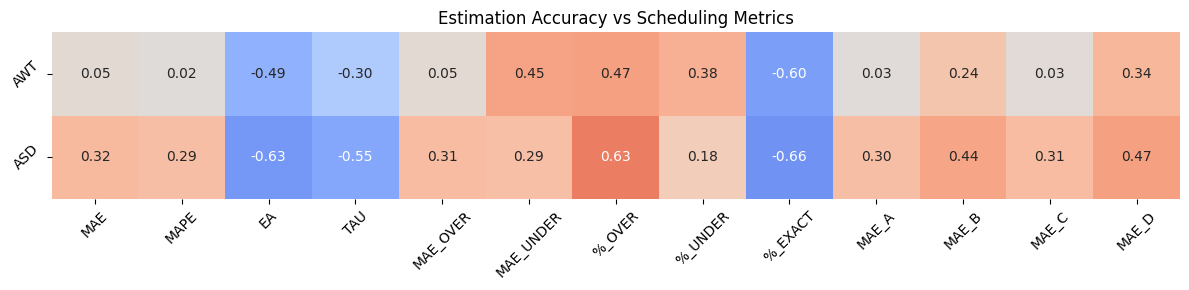

In [98]:
plt.figure(figsize=(12, 3))
sns.heatmap(corr.iloc[0:2, -13:], annot=True, cmap="coolwarm", fmt=".2f", cbar=False, vmin=-1, vmax=1)
plt.tick_params(axis='x', labelrotation=45)
plt.tick_params(axis='y', labelrotation=45)
plt.title("Estimation Accuracy vs Scheduling Metrics")
plt.tight_layout()
plt.savefig("images/66000x980/correlation_all_M1.png", dpi=300)
plt.show()

In [27]:
corr_cols = [
    "AWT", "ASD", # "ASU",
    "MAE", "MAPE", "EA", "TAU"
]

corr = summary_df[corr_cols].corr()

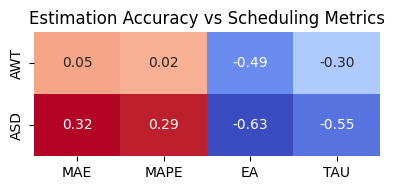

In [28]:
plt.figure(figsize=(4, 2))
sns.heatmap(corr.iloc[0:2, -4:], annot=True, cmap="coolwarm", fmt=".2f", cbar=False)
plt.title("Estimation Accuracy vs Scheduling Metrics")
plt.tight_layout()
plt.show()

In [29]:
corr_cols = [
    "AWT", "ASD", # "ASU",
    "MAE_OVER", "MAE_UNDER", "%_OVER", "%_UNDER", "%_EXACT"
]

corr = summary_df[corr_cols].corr()

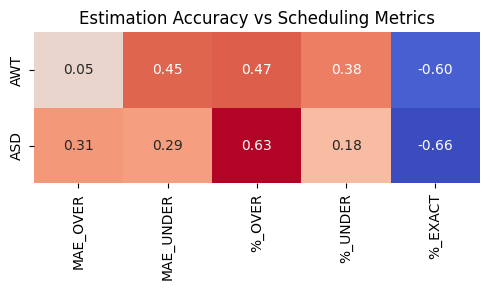

In [30]:
plt.figure(figsize=(5, 3))
sns.heatmap(corr.iloc[0:2, -5:], annot=True, cmap="coolwarm", fmt=".2f", cbar=False)
plt.title("Estimation Accuracy vs Scheduling Metrics")
plt.tight_layout()
plt.show()

In [31]:
corr_cols = [
    "AWT", "ASD", # "ASU",
    "MAE_A", "MAE_B", "MAE_C", "MAE_D"
    
]

corr = summary_df[corr_cols].corr()

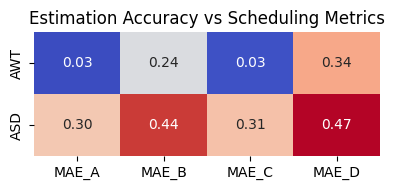

In [32]:
plt.figure(figsize=(4, 2))
sns.heatmap(corr.iloc[0:2, -4:], annot=True, cmap="coolwarm", fmt=".2f", cbar=False)
plt.title("Estimation Accuracy vs Scheduling Metrics")
plt.tight_layout()
plt.show()

### Scatter plots: Accuracy → Performance

#### Data Preparation

In [33]:
summary_df

,Workload,Policy,Estimation,AWT,ASD,ASU,Average Error,MAE,MAPE,EA,TAU,MAE_OVER,MAE_UNDER,%_OVER,%_UNDER,%_EXACT,MAE_A,MAE_B,MAE_C,MAE_D
0,Normal,1 - SJF,1 - User,314.56,3.39,41.438490,15:40:16,56416.198364,2999.341407,0.107134,-0.441967,56416.198364,0.000000,1.000000,0.000000,0.000000,66992.699852,25339.566412,58617.308039,35295.568528
1,Normal,1 - SJF,2 - Actual,297.49,1.46,41.438490,00:00:00,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
2,Normal,1 - SJF,3 - Heuristic,334.88,2.58,41.438490,01:01:35,3695.931497,53.277426,0.248127,0.320968,2096.918202,8785.644558,0.758539,0.239634,0.001828,1782.750845,9371.084486,1049.400643,20768.548223
3,Normal,1 - SJF,4 - DT,323.70,2.42,41.438490,00:56:07,3367.512313,3.901901,0.578268,0.669683,3262.773433,5234.749602,0.427512,0.376835,0.195653,1001.674190,10288.942140,1588.455305,20762.949239
4,Normal,1 - SJF,5 - RNP,321.21,2.40,41.438490,01:15:06,4506.397537,12.230835,0.562610,0.549939,7738.087200,4337.123422,0.361615,0.393852,0.244532,2034.655000,11502.112263,3950.100322,32114.309645
5,Normal,1 - SJF,6 - KNN,326.67,3.38,41.438490,00:59:17,3557.569267,96.500035,0.275680,0.226877,3009.026295,5871.905144,0.799853,0.195982,0.004164,2619.284380,6152.703239,3733.145338,16046.096447
6,Normal,1 - SJF,7 - LLM,325.20,2.09,41.438490,00:06:34,394.735919,1.621773,0.686491,0.747376,499.482402,1827.214101,0.409431,0.104110,0.486458,143.982006,1140.682557,93.766559,2092.279188
7,Normal,2 - EASYBF,1 - User,312.48,2.66,41.438491,15:40:16,56416.198364,2999.341407,0.107134,-0.441967,56416.198364,0.000000,1.000000,0.000000,0.000000,66992.699852,25339.566412,58617.308039,35295.568528
8,Normal,2 - EASYBF,2 - Actual,312.48,2.66,41.438491,00:00:00,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
9,Normal,2 - EASYBF,3 - Heuristic,312.48,2.66,41.438491,01:01:35,3695.931497,53.277426,0.248127,0.320968,2096.918202,8785.644558,0.758539,0.239634,0.001828,1782.750845,9371.084486,1049.400643,20768.548223


In [34]:
summary_df_avg = (
    summary_df
    .groupby(["Policy", "Estimation"])
    .agg({
        "AWT": "mean",
        "ASD": "mean",
        "ASU": "mean",
        "MAE": "mean",
        "MAPE": "mean",
        "EA": "mean",
        "TAU": "mean"
    })
    .reset_index()
)


In [35]:
summary_df_no_user = summary_df[summary_df['Estimation'] != '1 - User']
summary_df_avg_no_user = summary_df_avg[summary_df_avg['Estimation'] != '1 - User']

#### Plots

In [36]:
def accuracy_vs_metric_by_policy(data, acc_metric, sched_metric):
    g = sns.FacetGrid(
        data,
        col="Policy",
        col_wrap=3,
        height=4,
        sharex=True,
        sharey=True
    )
    g.map_dataframe(
        sns.scatterplot,
        x=acc_metric,
        y=sched_metric,
        hue="Estimation",
        s=100
    )
    g.add_legend()
    g.set_titles("{col_name}")
    g.fig.suptitle(f"{sched_metric} vs {acc_metric} (by Policy)", y=1.05)
    plt.show()


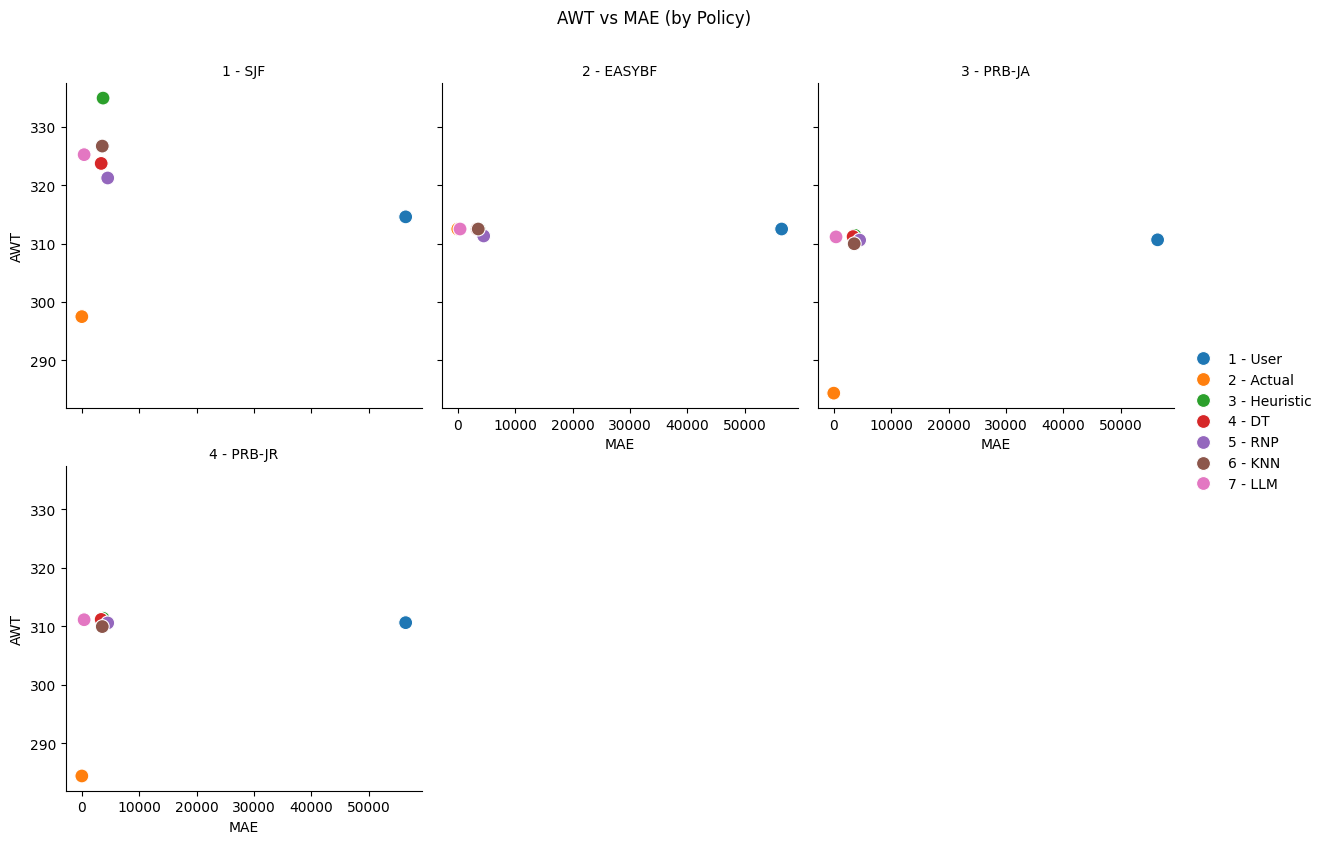

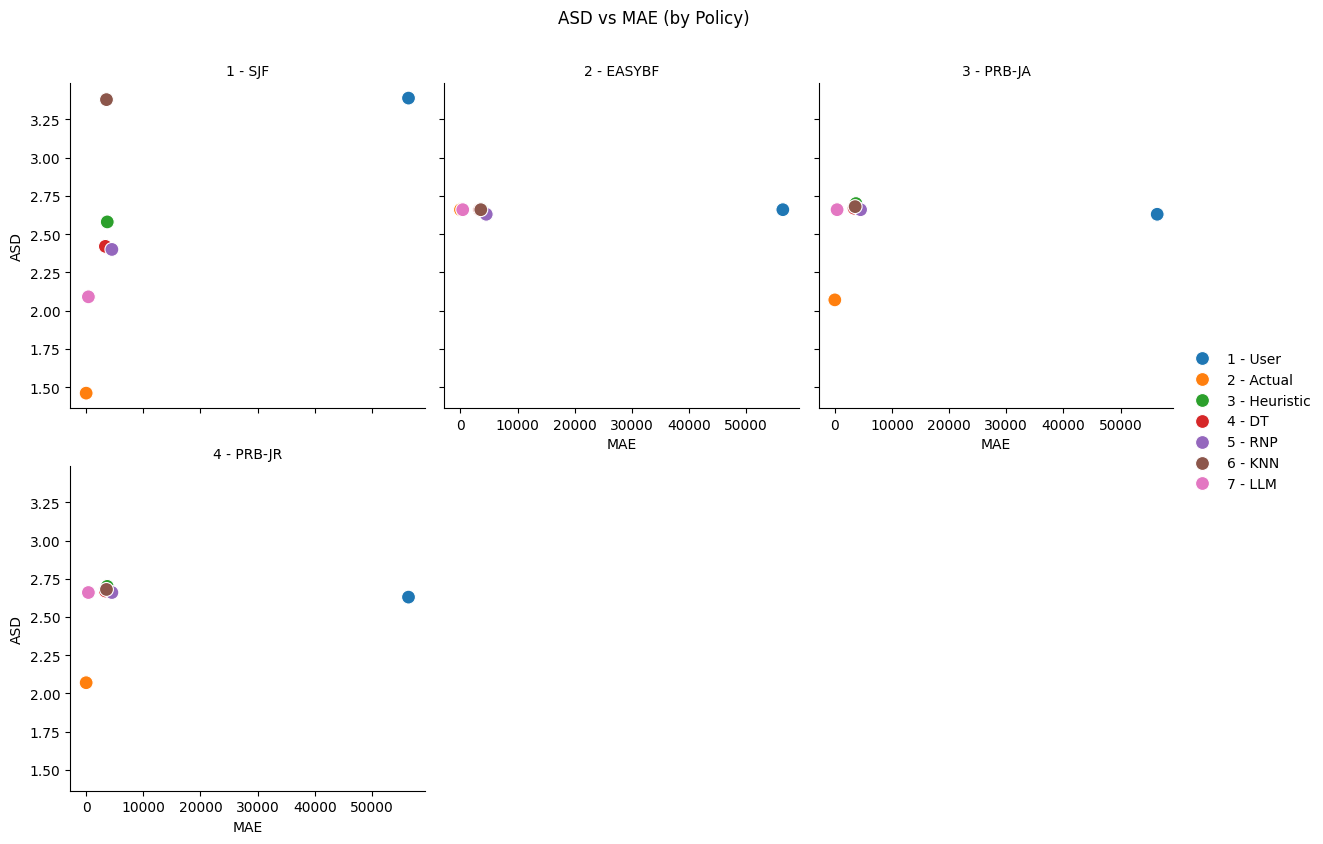

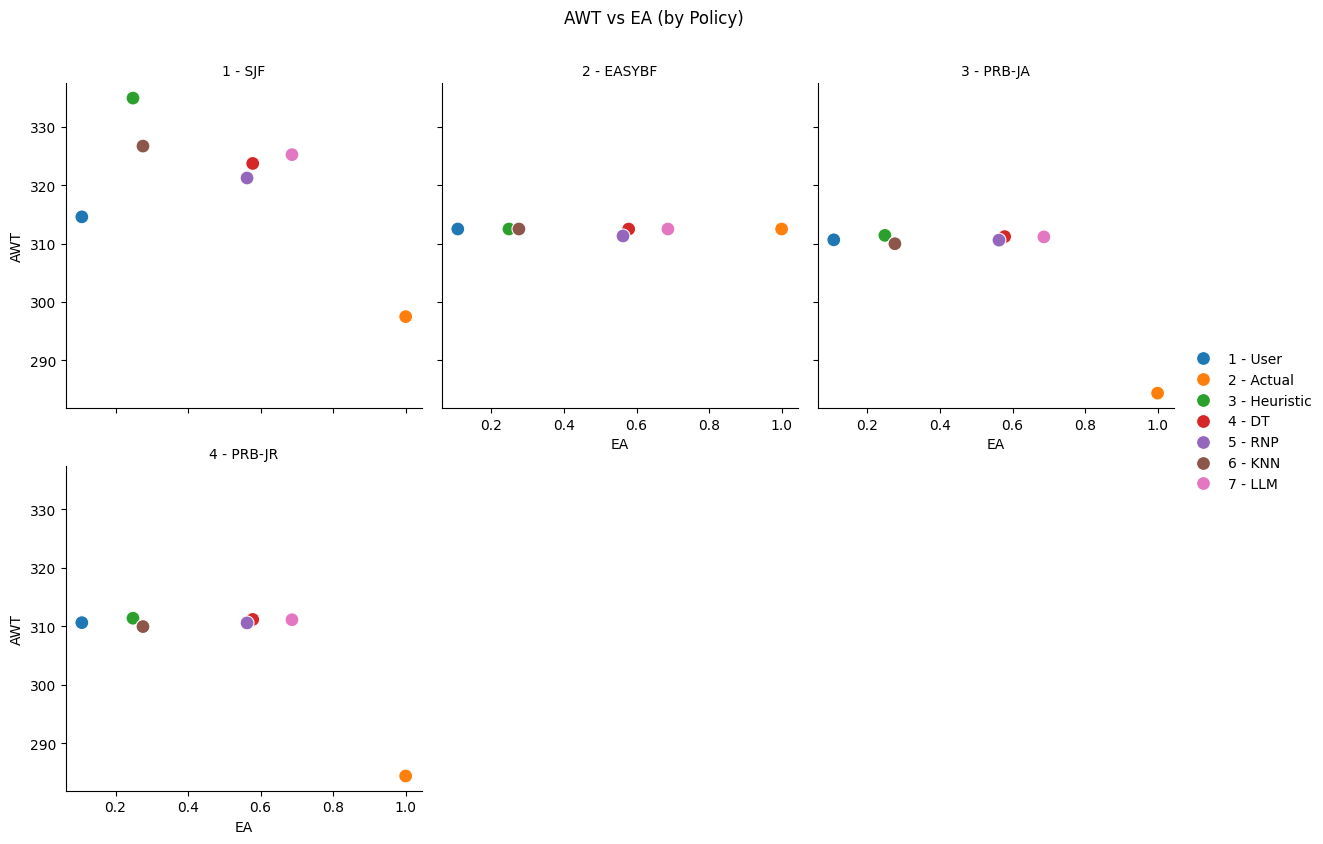

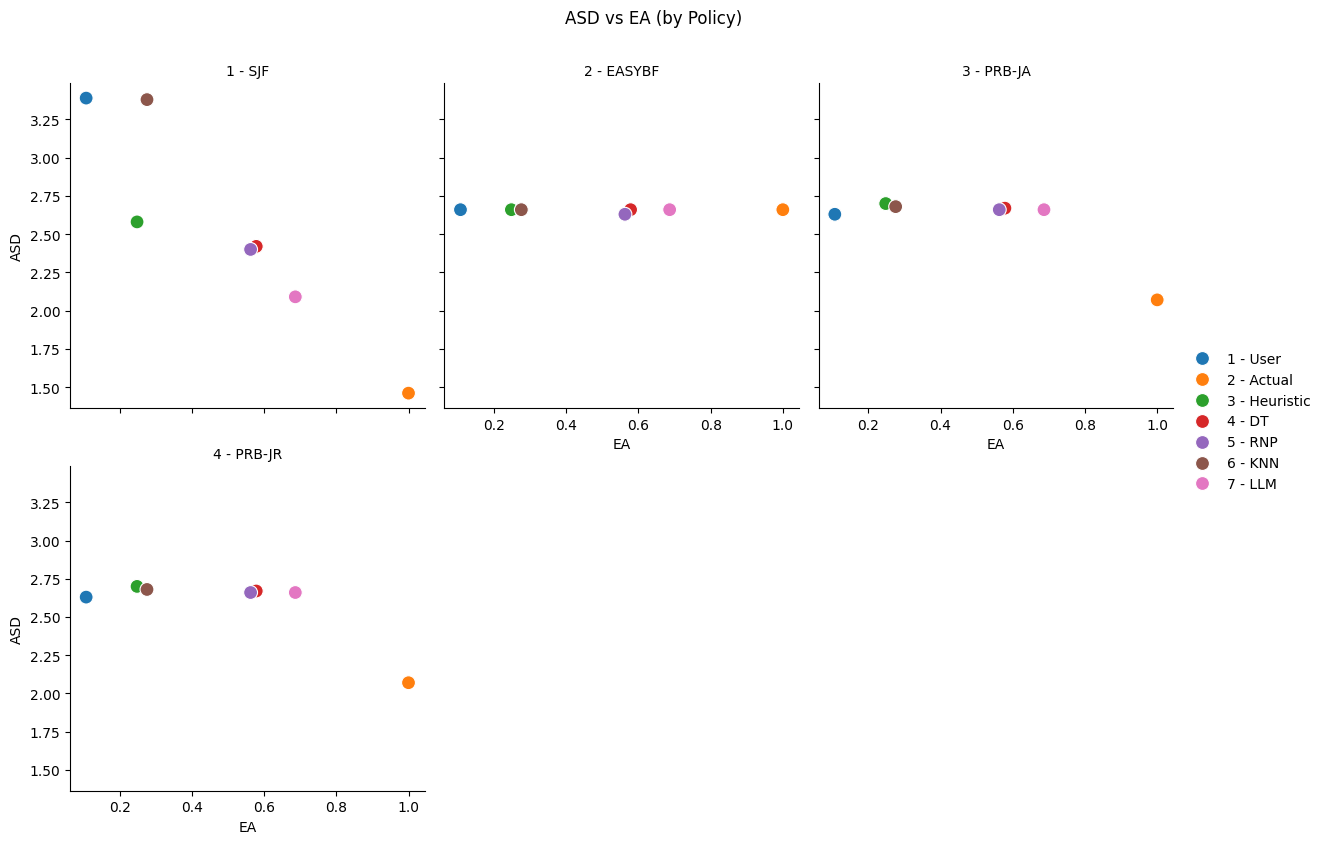

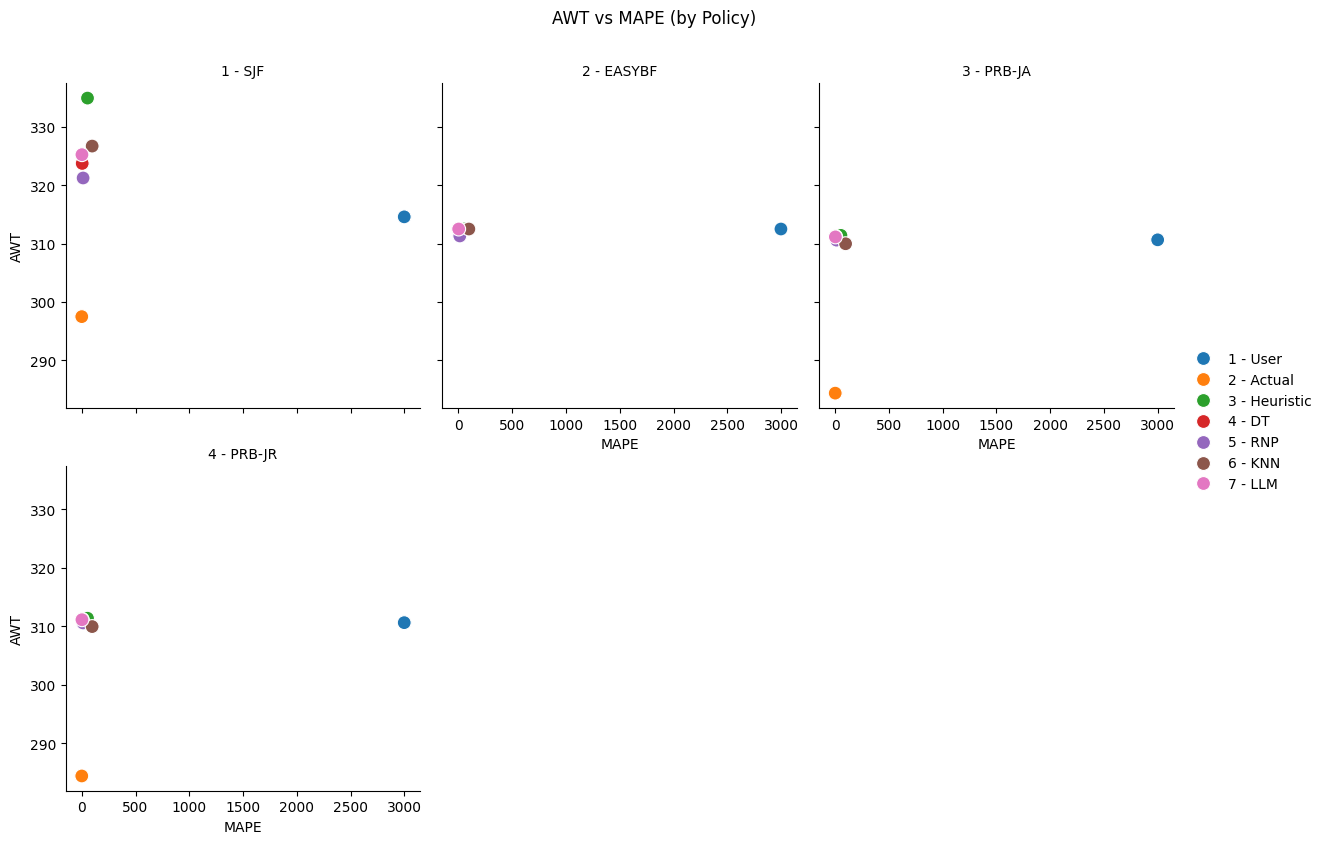

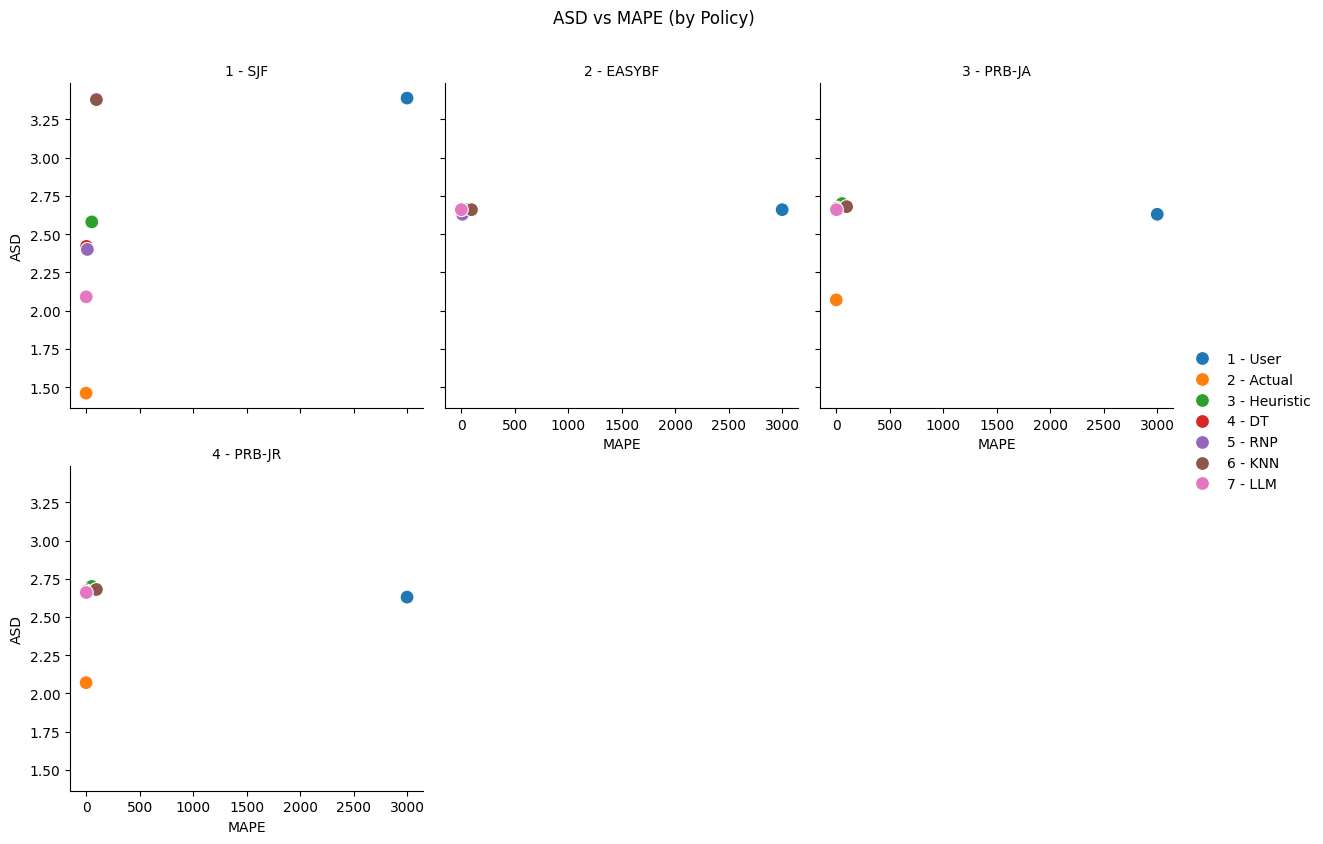

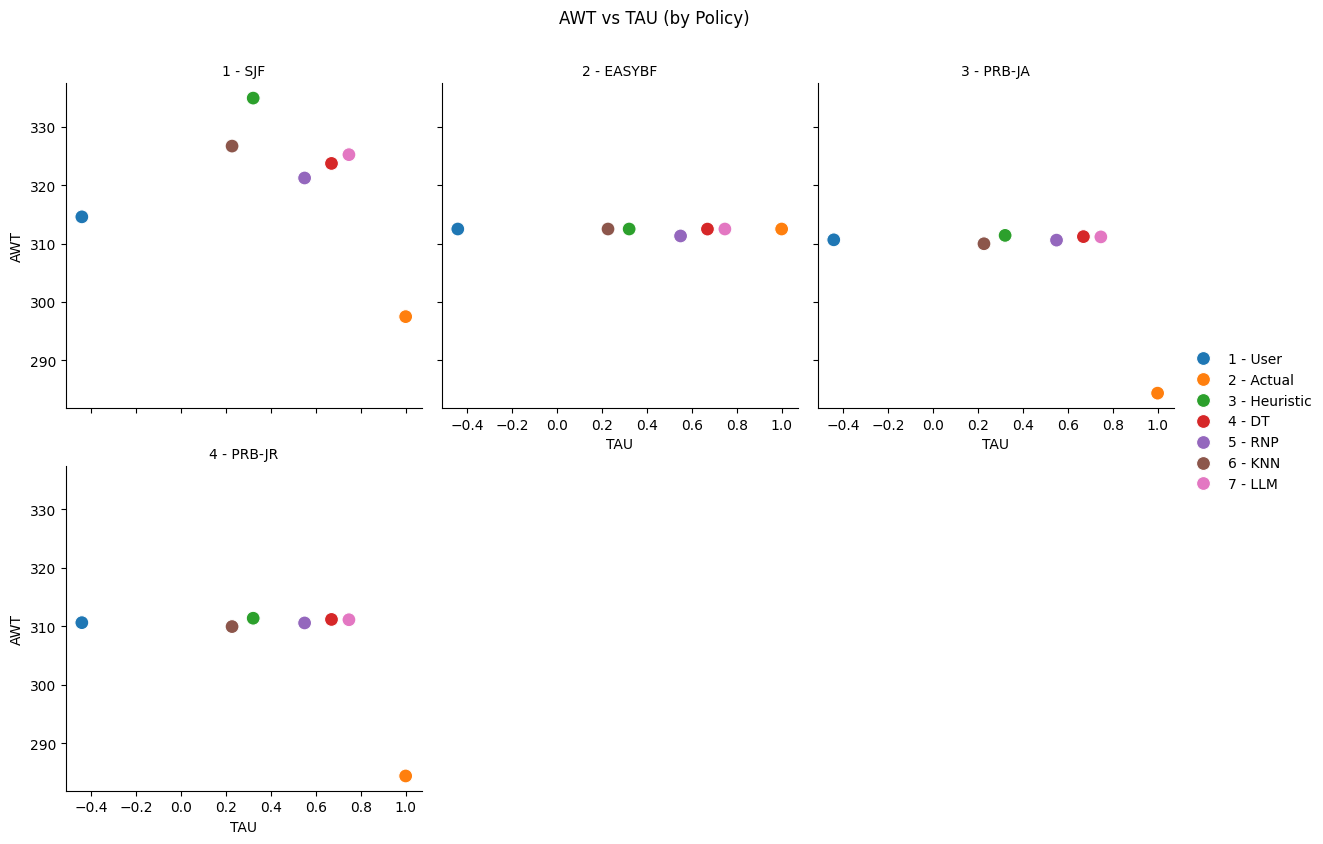

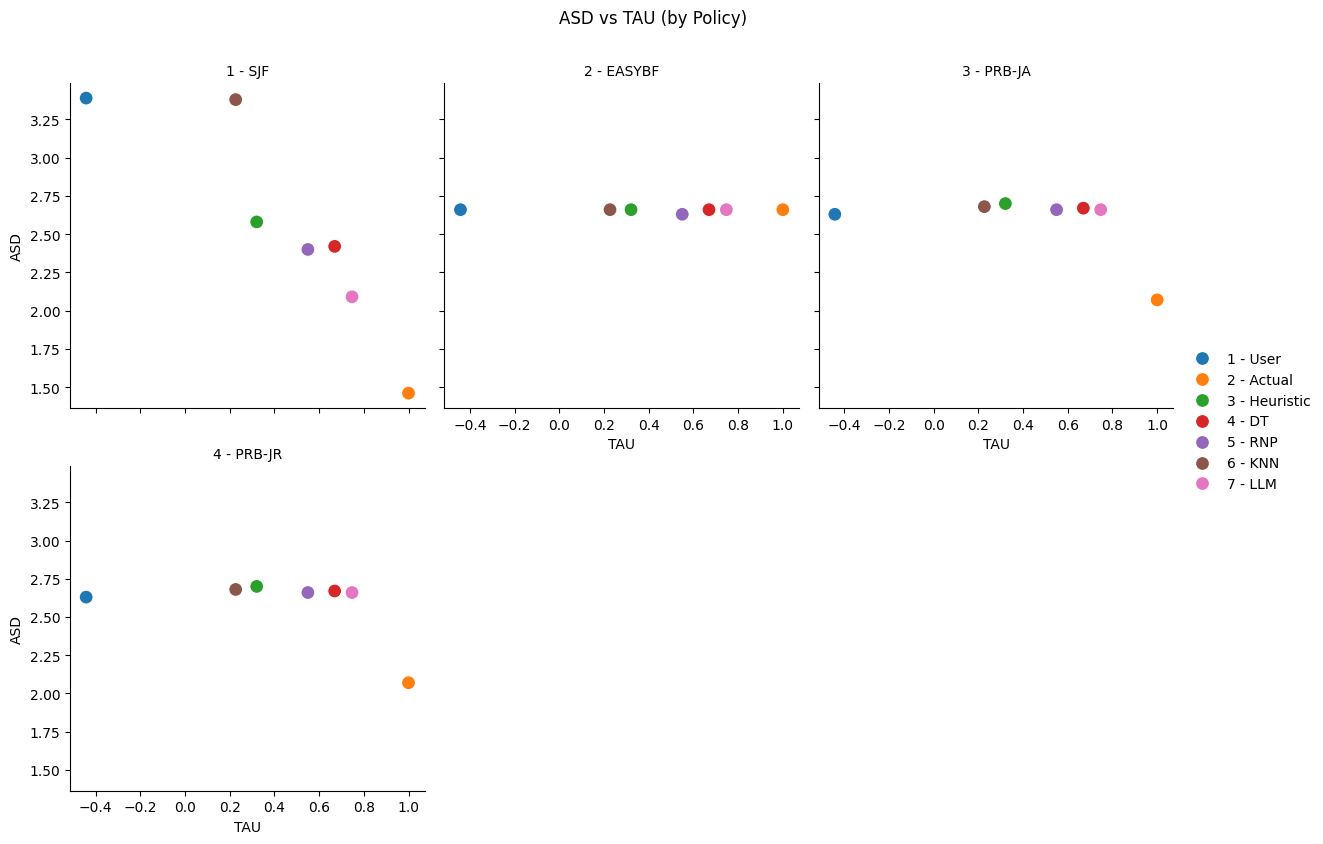

In [37]:
accuracy_vs_metric_by_policy(summary_df_avg, "MAE", "AWT")
accuracy_vs_metric_by_policy(summary_df_avg, "MAE", "ASD")

accuracy_vs_metric_by_policy(summary_df_avg, "EA", "AWT")
accuracy_vs_metric_by_policy(summary_df_avg, "EA", "ASD")

accuracy_vs_metric_by_policy(summary_df_avg, "MAPE", "AWT")
accuracy_vs_metric_by_policy(summary_df_avg, "MAPE", "ASD")

accuracy_vs_metric_by_policy(summary_df_avg, "TAU", "AWT")
accuracy_vs_metric_by_policy(summary_df_avg, "TAU", "ASD")

### Metrics Regression

#### Helpers

In [38]:
def plot_feature_importance(model, X, title):
    importances = model.feature_importances_
    indices = np.argsort(importances)

    plt.figure()
    plt.barh(range(len(indices)), importances[indices])
    plt.yticks(range(len(indices)), X.columns[indices])
    plt.xlabel("Importance")
    plt.title(title)
    plt.show()

In [39]:
def plot_permutation_importance(model, X, y, title):
    result = permutation_importance(
        model, X, y,
        n_repeats=30,
        random_state=42
    )

    sorted_idx = result.importances_mean.argsort()

    plt.figure()
    plt.barh(X.columns[sorted_idx], result.importances_mean[sorted_idx])
    plt.xlabel("Permutation Importance")
    plt.title(title)
    plt.show()

In [40]:
def plot_pdp(model, X, features, title, size=(12, 12)):
    fig, ax = plt.subplots(figsize=size)

    PartialDependenceDisplay.from_estimator(
        model,
        X,
        features,
        ax=ax
    )

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

#### Random Forest - All Metrics

In [41]:
features = [
    "MAE", "MAPE", "EA", "TAU",
    "MAE_OVER", "MAE_UNDER",
    "%_OVER", "%_UNDER", "%_EXACT",
    "MAE_A", "MAE_B", "MAE_C", "MAE_D"
]

X = summary_df[features]

# --- targets
y_awt = summary_df["AWT"]
y_asd = summary_df["ASD"]

In [42]:
rf_awt = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

rf_asd = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

rf_awt.fit(X, y_awt)
rf_asd.fit(X, y_asd)

RandomForestRegressor(n_estimators=300, random_state=42)

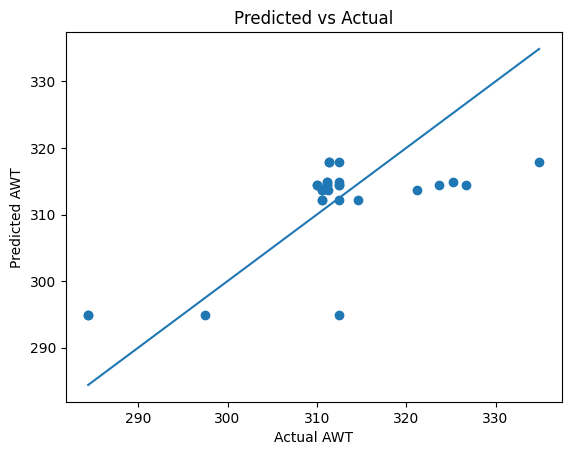

In [43]:
y_pred = rf_awt.predict(X)

plt.figure()
plt.scatter(y_awt, y_pred)
plt.xlabel("Actual AWT")
plt.ylabel("Predicted AWT")
plt.title("Predicted vs Actual")
plt.plot([y_awt.min(), y_awt.max()],
         [y_awt.min(), y_awt.max()])
plt.show()

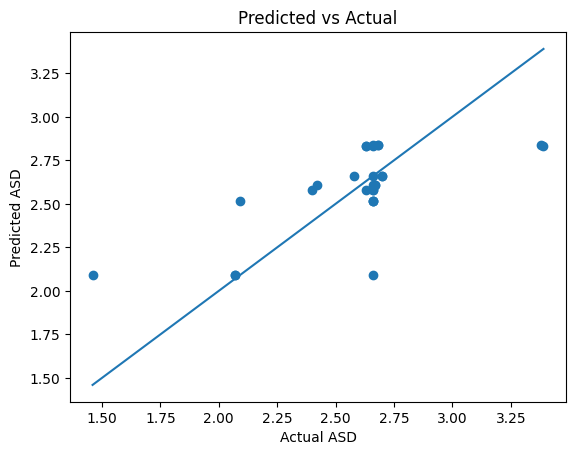

In [44]:
y_pred = rf_asd.predict(X)

plt.figure()
plt.scatter(y_asd, y_pred)
plt.xlabel("Actual ASD")
plt.ylabel("Predicted ASD")
plt.title("Predicted vs Actual")
plt.plot([y_asd.min(), y_asd.max()],
         [y_asd.min(), y_asd.max()])
plt.show()

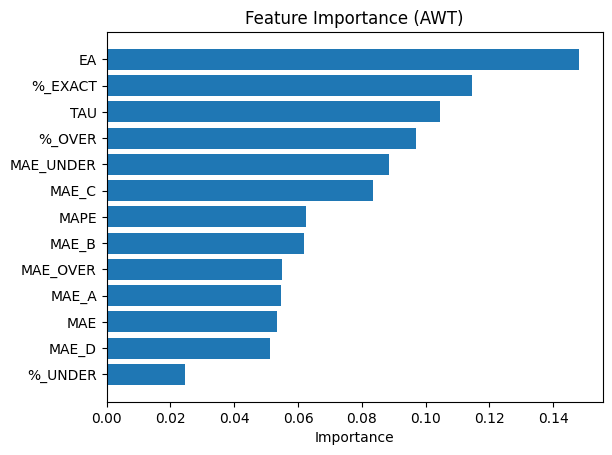

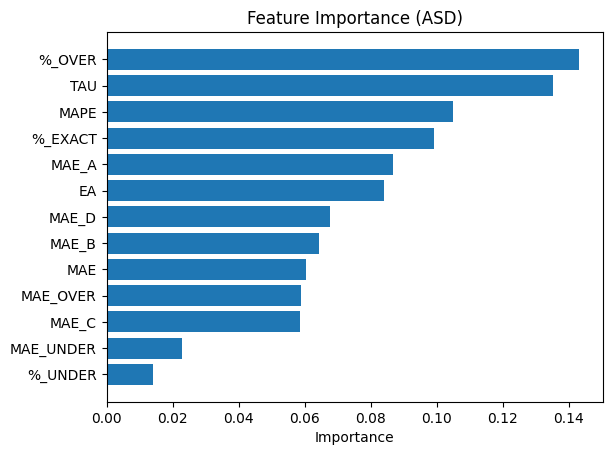

In [45]:
plot_feature_importance(rf_awt, X, "Feature Importance (AWT)")
plot_feature_importance(rf_asd, X, "Feature Importance (ASD)")

#### Random Forest - Reduced Metrics

In [46]:
features = [
    "MAE", "MAPE", "EA", "TAU",
    "MAE_OVER", "MAE_UNDER",
    "%_OVER", "%_UNDER", "%_EXACT"]

X = summary_df[features]

# --- targets
y_awt = summary_df["AWT"]
y_asd = summary_df["ASD"]

In [47]:
rf_awt = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

rf_asd = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

rf_awt.fit(X, y_awt)
rf_asd.fit(X, y_asd)

RandomForestRegressor(n_estimators=300, random_state=42)

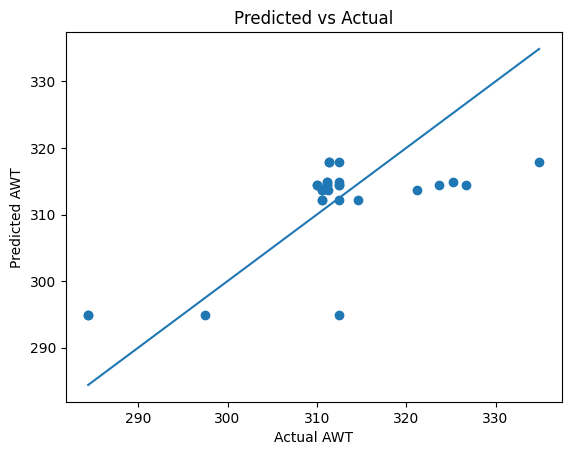

In [48]:
y_pred = rf_awt.predict(X)

plt.figure()
plt.scatter(y_awt, y_pred)
plt.xlabel("Actual AWT")
plt.ylabel("Predicted AWT")
plt.title("Predicted vs Actual")
plt.plot([y_awt.min(), y_awt.max()],
         [y_awt.min(), y_awt.max()])
plt.show()

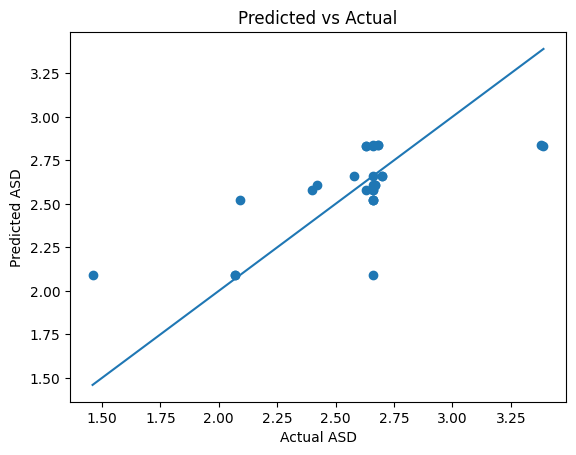

In [49]:
y_pred = rf_asd.predict(X)

plt.figure()
plt.scatter(y_asd, y_pred)
plt.xlabel("Actual ASD")
plt.ylabel("Predicted ASD")
plt.title("Predicted vs Actual")
plt.plot([y_asd.min(), y_asd.max()],
         [y_asd.min(), y_asd.max()])
plt.show()

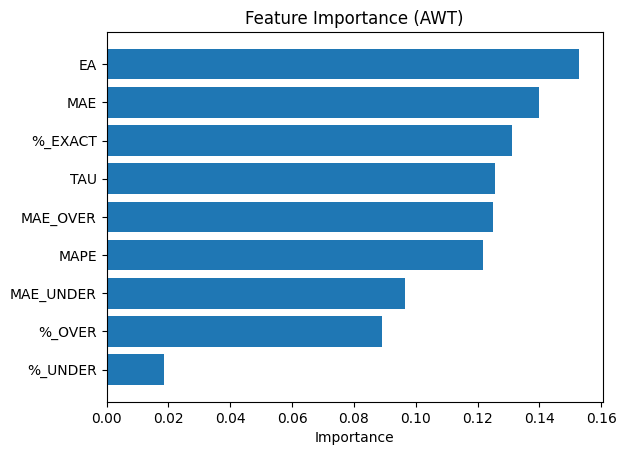

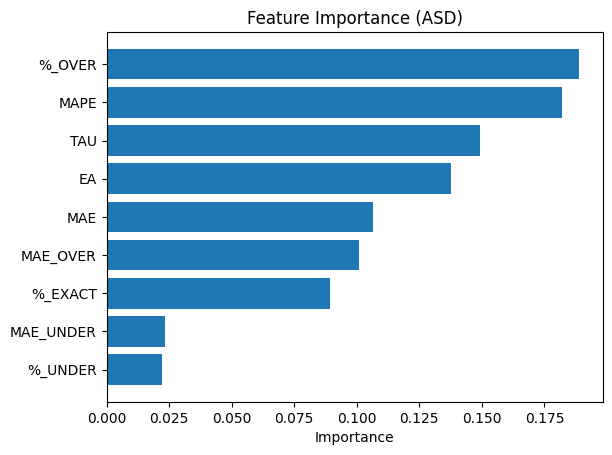

In [50]:
plot_feature_importance(rf_awt, X, "Feature Importance (AWT)")
plot_feature_importance(rf_asd, X, "Feature Importance (ASD)")

## SJF-specific Analysis

### Data Preprocessing

In [51]:
summary_df_sjf = summary_df[summary_df["Policy"] == "1 - SJF"]

In [52]:
summary_df_sjf

,Workload,Policy,Estimation,AWT,ASD,ASU,Average Error,MAE,MAPE,EA,TAU,MAE_OVER,MAE_UNDER,%_OVER,%_UNDER,%_EXACT,MAE_A,MAE_B,MAE_C,MAE_D
0,Normal,1 - SJF,1 - User,314.56,3.39,41.43849,15:40:16,56416.198364,2999.341407,0.107134,-0.441967,56416.198364,0.000000,1.000000,0.000000,0.000000,66992.699852,25339.566412,58617.308039,35295.568528
1,Normal,1 - SJF,2 - Actual,297.49,1.46,41.43849,00:00:00,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
2,Normal,1 - SJF,3 - Heuristic,334.88,2.58,41.43849,01:01:35,3695.931497,53.277426,0.248127,0.320968,2096.918202,8785.644558,0.758539,0.239634,0.001828,1782.750845,9371.084486,1049.400643,20768.548223
3,Normal,1 - SJF,4 - DT,323.70,2.42,41.43849,00:56:07,3367.512313,3.901901,0.578268,0.669683,3262.773433,5234.749602,0.427512,0.376835,0.195653,1001.674190,10288.942140,1588.455305,20762.949239
4,Normal,1 - SJF,5 - RNP,321.21,2.40,41.43849,01:15:06,4506.397537,12.230835,0.562610,0.549939,7738.087200,4337.123422,0.361615,0.393852,0.244532,2034.655000,11502.112263,3950.100322,32114.309645
5,Normal,1 - SJF,6 - KNN,326.67,3.38,41.43849,00:59:17,3557.569267,96.500035,0.275680,0.226877,3009.026295,5871.905144,0.799853,0.195982,0.004164,2619.284380,6152.703239,3733.145338,16046.096447
6,Normal,1 - SJF,7 - LLM,325.20,2.09,41.43849,00:06:34,394.735919,1.621773,0.686491,0.747376,499.482402,1827.214101,0.409431,0.104110,0.486458,143.982006,1140.682557,93.766559,2092.279188


In [53]:
summary_df_sjf_avg = (
    summary_df_sjf
    .groupby(["Policy", "Estimation"])
    .agg({
        "AWT": "mean",
        "ASD": "mean",
        "ASU": "mean",
        "MAE": "mean",
        "MAPE": "mean",
        "EA": "mean",
        "TAU": "mean",
        "MAE_OVER": "mean",
        "MAE_UNDER": "mean",
        "MAE_A": "mean",
        "MAE_B": "mean",
        "MAE_C": "mean",
        "MAE_D": "mean",
        "%_OVER": "mean",
        "%_UNDER": "mean",
        "%_EXACT": "mean"
    })
    .reset_index()
)

In [54]:
summary_df_sjf_avg

,Policy,Estimation,AWT,ASD,ASU,MAE,MAPE,EA,TAU,MAE_OVER,MAE_UNDER,MAE_A,MAE_B,MAE_C,MAE_D,%_OVER,%_UNDER,%_EXACT
0,1 - SJF,1 - User,314.56,3.39,41.43849,56416.198364,2999.341407,0.107134,-0.441967,56416.198364,0.000000,66992.699852,25339.566412,58617.308039,35295.568528,1.000000,0.000000,0.000000
1,1 - SJF,2 - Actual,297.49,1.46,41.43849,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
2,1 - SJF,3 - Heuristic,334.88,2.58,41.43849,3695.931497,53.277426,0.248127,0.320968,2096.918202,8785.644558,1782.750845,9371.084486,1049.400643,20768.548223,0.758539,0.239634,0.001828
3,1 - SJF,4 - DT,323.70,2.42,41.43849,3367.512313,3.901901,0.578268,0.669683,3262.773433,5234.749602,1001.674190,10288.942140,1588.455305,20762.949239,0.427512,0.376835,0.195653
4,1 - SJF,5 - RNP,321.21,2.40,41.43849,4506.397537,12.230835,0.562610,0.549939,7738.087200,4337.123422,2034.655000,11502.112263,3950.100322,32114.309645,0.361615,0.393852,0.244532
5,1 - SJF,6 - KNN,326.67,3.38,41.43849,3557.569267,96.500035,0.275680,0.226877,3009.026295,5871.905144,2619.284380,6152.703239,3733.145338,16046.096447,0.799853,0.195982,0.004164
6,1 - SJF,7 - LLM,325.20,2.09,41.43849,394.735919,1.621773,0.686491,0.747376,499.482402,1827.214101,143.982006,1140.682557,93.766559,2092.279188,0.409431,0.104110,0.486458


In [55]:
predictions = pd.read_csv("predictions/pm100/predictions.csv")

w_1 = pd.read_csv('workloads/pm100/pm100.swf', header=None, sep='\t')

pred_w_1 = predictions[predictions["job_id"].isin(w_1[0].values)]

In [56]:
ESTIMATION_COL_MAP = {
    "1 - User": "pred_runtime_user",
    "3 - Heuristic": "pred_runtime_heuristic",
    "4 - DT": "pred_runtime_dt_fs2",
    "5 - RNP": "pred_runtime_rnp_fs2",
    "6 - KNN": "pred_runtime_knn_fs2",
    "7 - LLM": "pred_runtime_ora",
}

pred_dfs = {
    "Normal": pred_w_1
}


In [57]:
job_rows = []

for workload, df in pred_dfs.items():
    for est_label, pred_col in ESTIMATION_COL_MAP.items():

        tmp = df[[
            "job_id",
            "user_id",
            "time_submit",
            "gt_runtime",
            pred_col
        ]].copy()

        tmp = tmp.rename(columns={
            pred_col: "predicted_runtime",
            "gt_runtime": "true_runtime"
        })

        tmp["Workload"] = workload
        tmp["Policy"] = "1 - SJF"
        tmp["Estimation"] = est_label

        job_rows.append(tmp)

job_df = pd.concat(job_rows, ignore_index=True)

In [58]:
job_df

,job_id,user_id,time_submit,true_runtime,predicted_runtime,Workload,Policy,Estimation
0,1597511,1711,11480812,4282,14400,Normal,1 - SJF,1 - User
1,4698474,1711,11480812,4534,14400,Normal,1 - SJF,1 - User
2,5211156,1711,11480812,1568,14400,Normal,1 - SJF,1 - User
3,3093839,1711,11480812,4606,14400,Normal,1 - SJF,1 - User
4,4194113,1711,11480812,4521,14400,Normal,1 - SJF,1 - User
...,...,...,...,...,...,...,...,...
400471,3214055,8,13832570,4,4,Normal,1 - SJF,7 - LLM
400472,558069,8,13833191,2,10,Normal,1 - SJF,7 - LLM
400473,1997479,8,13833813,3,3,Normal,1 - SJF,7 - LLM
400474,4424415,8,13834310,3,300,Normal,1 - SJF,7 - LLM


In [59]:
job_df[["true_runtime", "predicted_runtime"]].describe()

,true_runtime,predicted_runtime
count,400476.000000,400476.000000
mean,4136.368097,13751.653770
std,13178.036099,27397.867809
min,1.000000,1.000000
25%,1.000000,13.000000
50%,27.000000,1431.000000
75%,1665.000000,6000.000000
max,86395.000000,86400.000000


### Correlation Tables

In [94]:
corr_cols = [
    "AWT", "ASD", # "ASU",
    "MAE", "MAPE", "EA", "TAU",
    "MAE_OVER", "MAE_UNDER", "%_OVER", "%_UNDER", "%_EXACT",
    "MAE_A", "MAE_B", "MAE_C", "MAE_D"
]

corr = summary_df_sjf_avg[corr_cols].corr()

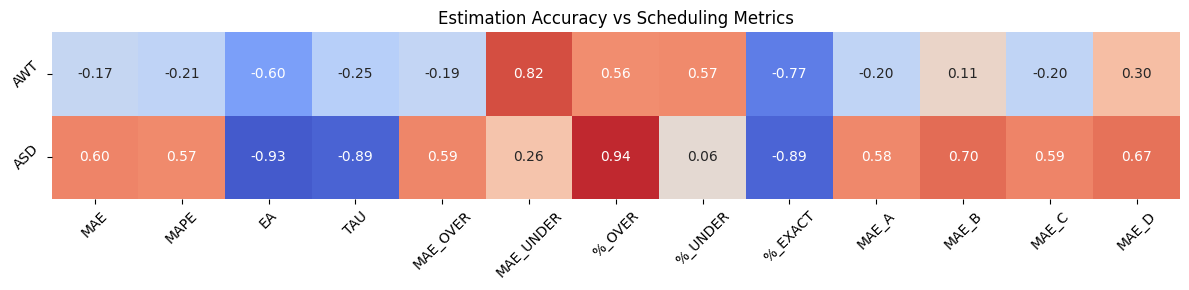

In [96]:
plt.figure(figsize=(12, 3))
sns.heatmap(corr.iloc[0:2, -13:], annot=True, cmap="coolwarm", fmt=".2f", cbar=False, vmin=-1, vmax=1)
plt.tick_params(axis='x', labelrotation=45)
plt.tick_params(axis='y', labelrotation=45)
plt.title("Estimation Accuracy vs Scheduling Metrics")
plt.tight_layout()
plt.savefig("images/66000x980/correlation_sjf_M1.png", dpi=300)
plt.show()

In [60]:
corr_cols = [
    "AWT", "ASD", # "ASU",
    "MAE", "MAPE", "EA", "TAU"
]

corr = summary_df_sjf_avg[corr_cols].corr()

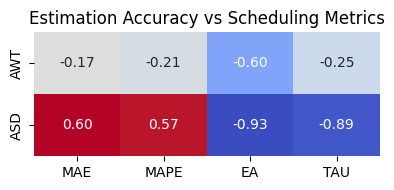

In [61]:
plt.figure(figsize=(4, 2))
sns.heatmap(corr.iloc[0:2, -4:], annot=True, cmap="coolwarm", fmt=".2f", cbar=False)
plt.title("Estimation Accuracy vs Scheduling Metrics")
plt.tight_layout()
plt.show()

In [62]:
corr_cols = [
    "AWT", "ASD", # "ASU",
    "MAE_OVER", "MAE_UNDER", "%_OVER", "%_UNDER", "%_EXACT"
]

corr = summary_df_sjf[corr_cols].corr()

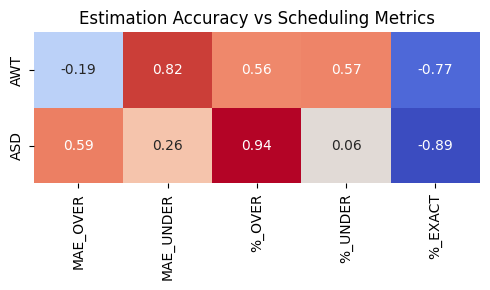

In [63]:
plt.figure(figsize=(5, 3))
sns.heatmap(corr.iloc[0:2, -5:], annot=True, cmap="coolwarm", fmt=".2f", cbar=False)
plt.title("Estimation Accuracy vs Scheduling Metrics")
plt.tight_layout()
plt.show()

In [64]:
corr_cols = [
    "AWT", "ASD", # "ASU",
    "MAE_A", "MAE_B", "MAE_C", "MAE_D"
]

corr = summary_df_sjf[corr_cols].corr()

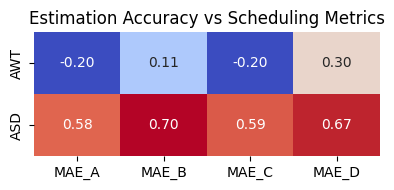

In [65]:
plt.figure(figsize=(4, 2))
sns.heatmap(corr.iloc[0:2, -4:], annot=True, cmap="coolwarm", fmt=".2f", cbar=False)
plt.title("Estimation Accuracy vs Scheduling Metrics")
plt.tight_layout()
plt.show()

### Scatter plots: Accuracy → Performance

In [66]:
def accuracy_vs_metrics_grid(data, acc_metrics, sched_metrics, size=(12, 12), image_path=""):
    fig, axes = plt.subplots(
        nrows=len(acc_metrics),
        ncols=len(sched_metrics),
        figsize=size,
        sharex=False,
        sharey=False
    )

    for i, acc_metric in enumerate(acc_metrics):
        for j, sched_metric in enumerate(sched_metrics):
            ax = axes[i, j]

            # Show legend only for last column
            show_legend = (j == len(sched_metrics) - 1)

            sns.scatterplot(
                data=data,
                x=acc_metric,
                y=sched_metric,
                hue="Estimation",
                s=50,
                ax=ax,
                legend=show_legend
            )

            ax.set_title(f"{sched_metric} vs {acc_metric}")
            ax.grid(True)

            # Move legend to the right of the last subplot
            if show_legend:
                handles, labels = ax.get_legend_handles_labels()
                ax.legend(
                    handles=handles,
                    labels=labels,
                    loc='center left',
                    bbox_to_anchor=(1.05, 0.5),
                    borderaxespad=0.
                )

    plt.tight_layout()

    # Add extra space on the right for legends
    plt.subplots_adjust(right=0.85)

    if image_path:
        plt.savefig(image_path, dpi=300, bbox_inches='tight')
        print(f"Grafico salvato in: {image_path}")

    plt.show()

Grafico salvato in: images/66000x980/scatter_plots_sjf_M1.png


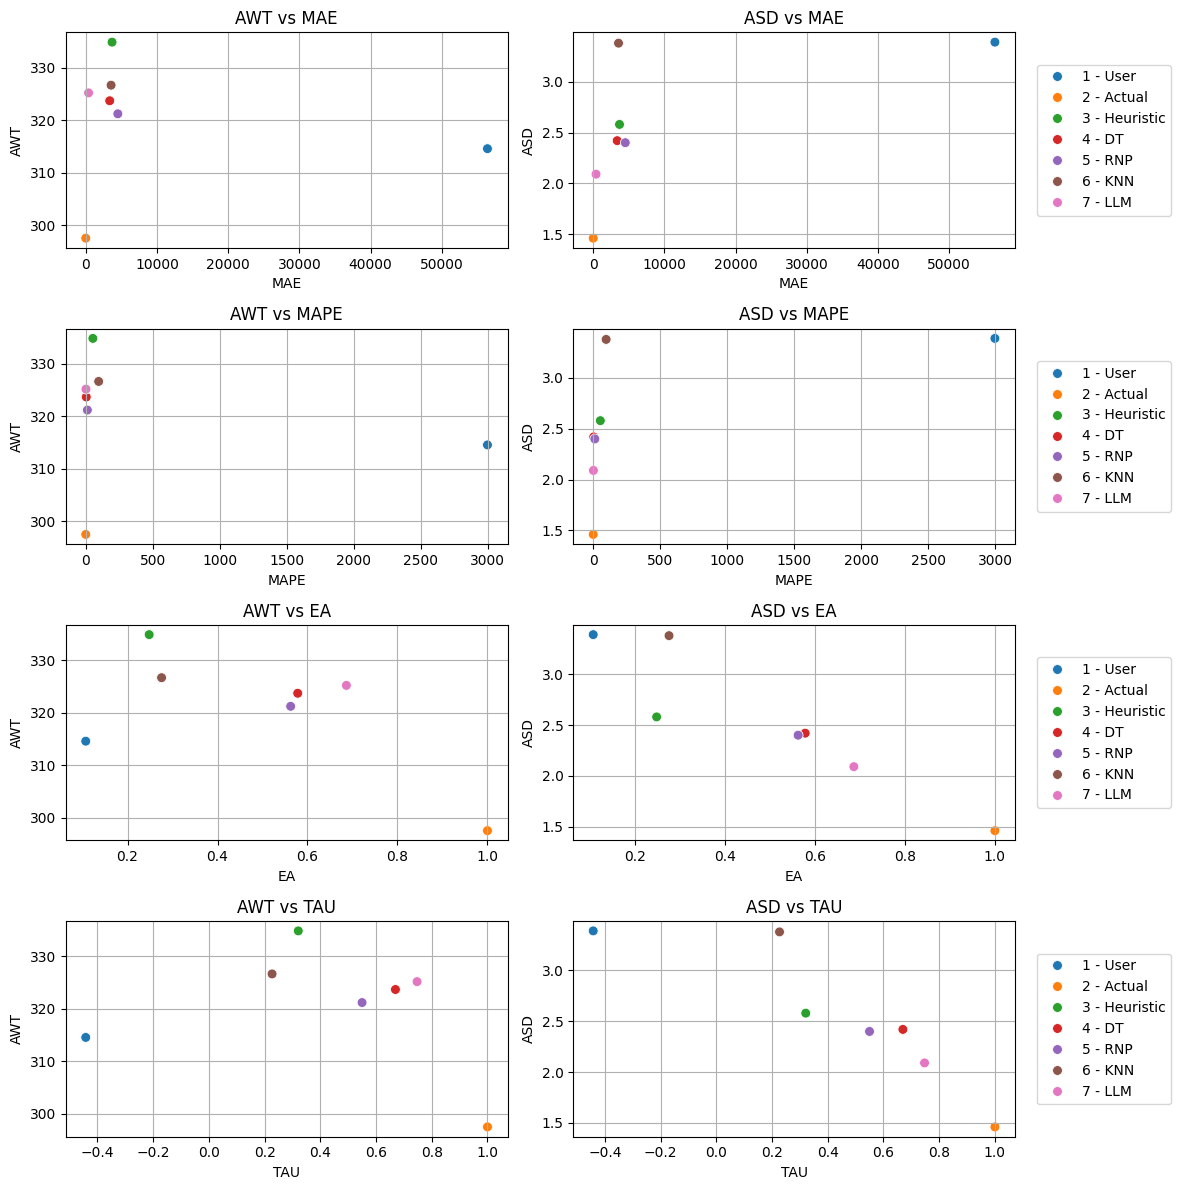

In [67]:
acc_metrics = ["MAE", "MAPE", "EA", "TAU"]
# sched_metrics = ["AWT", "ASD", "ASU"]
sched_metrics = ["AWT", "ASD"]

accuracy_vs_metrics_grid(summary_df_sjf_avg, acc_metrics, sched_metrics, image_path="images/66000x980/scatter_plots_sjf_M1.png")

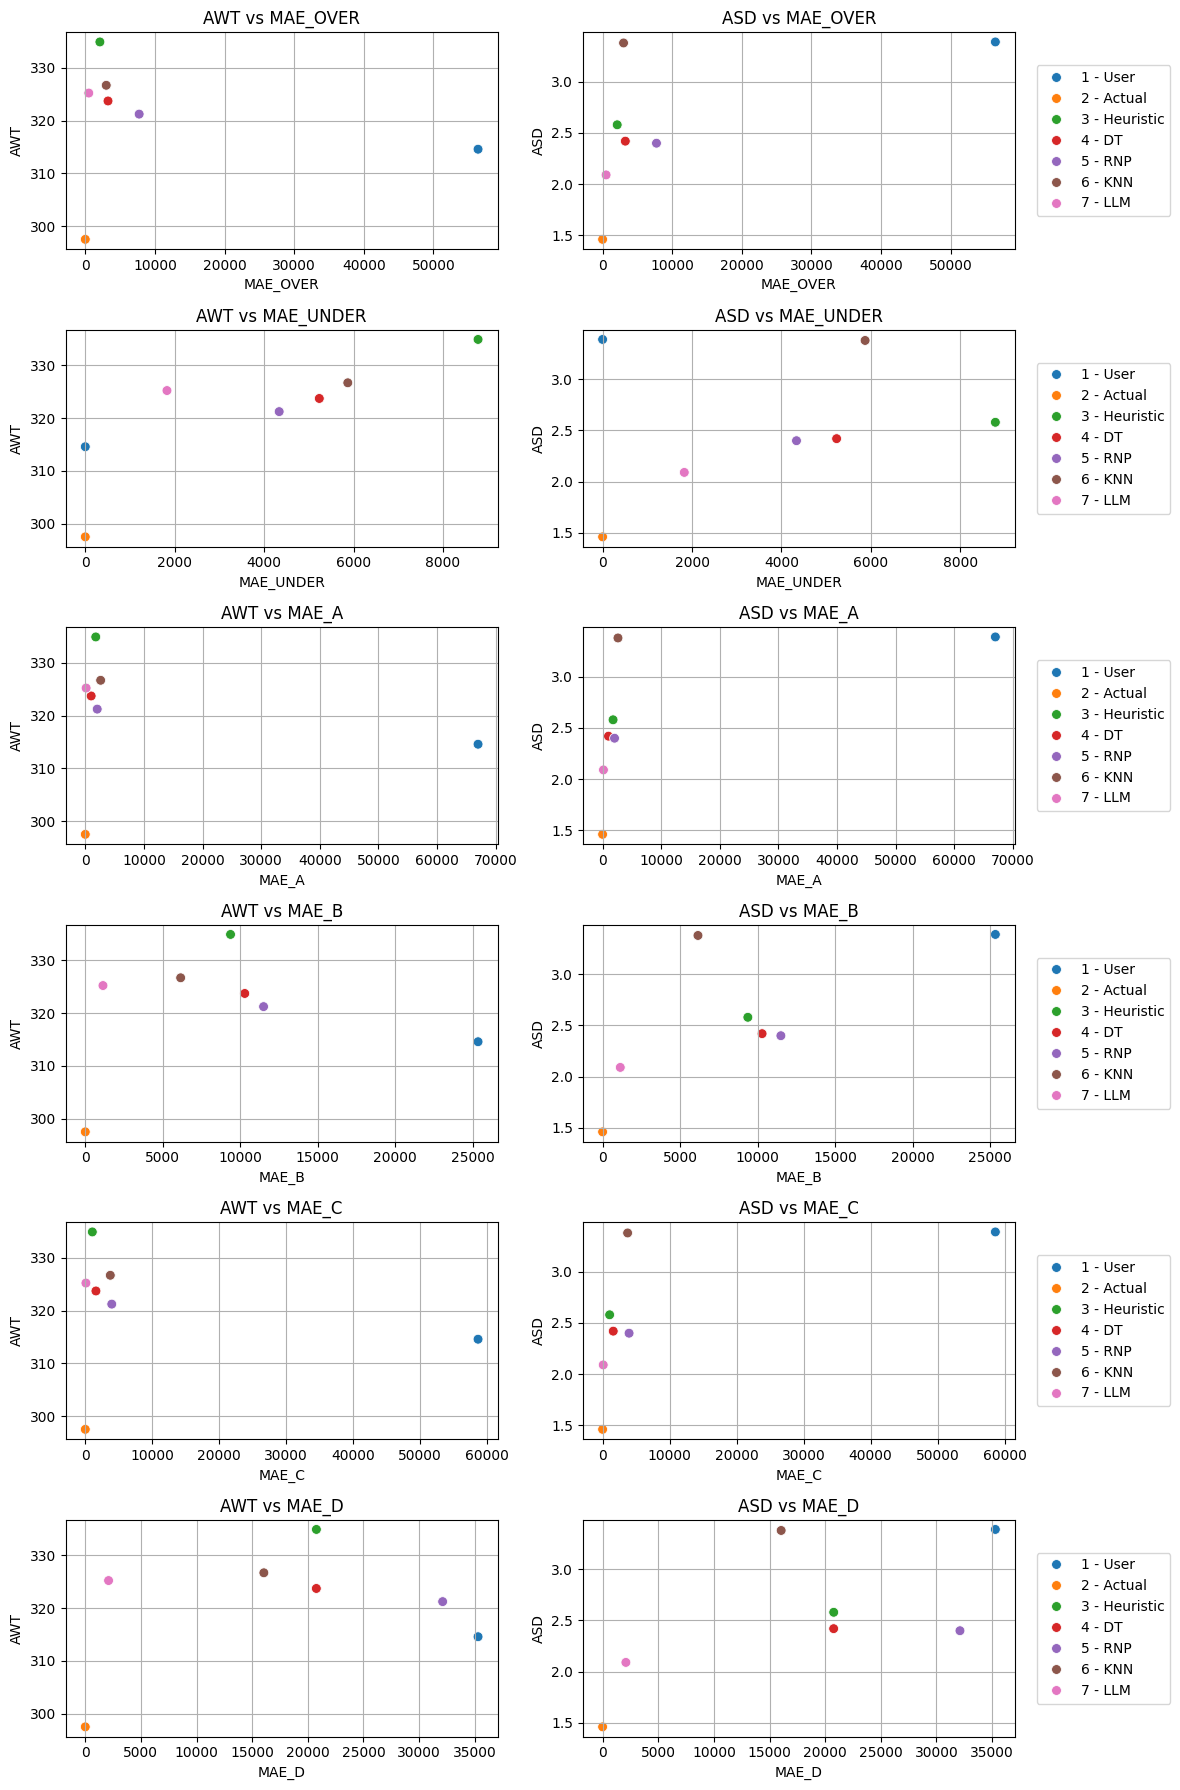

In [68]:
acc_metrics = ["MAE_OVER", "MAE_UNDER", "MAE_A", "MAE_B", "MAE_C", "MAE_D"]
# sched_metrics = ["AWT", "ASD", "ASU"]
sched_metrics = ["AWT", "ASD"]

accuracy_vs_metrics_grid(summary_df_sjf_avg, acc_metrics, sched_metrics, size=(12, 18))

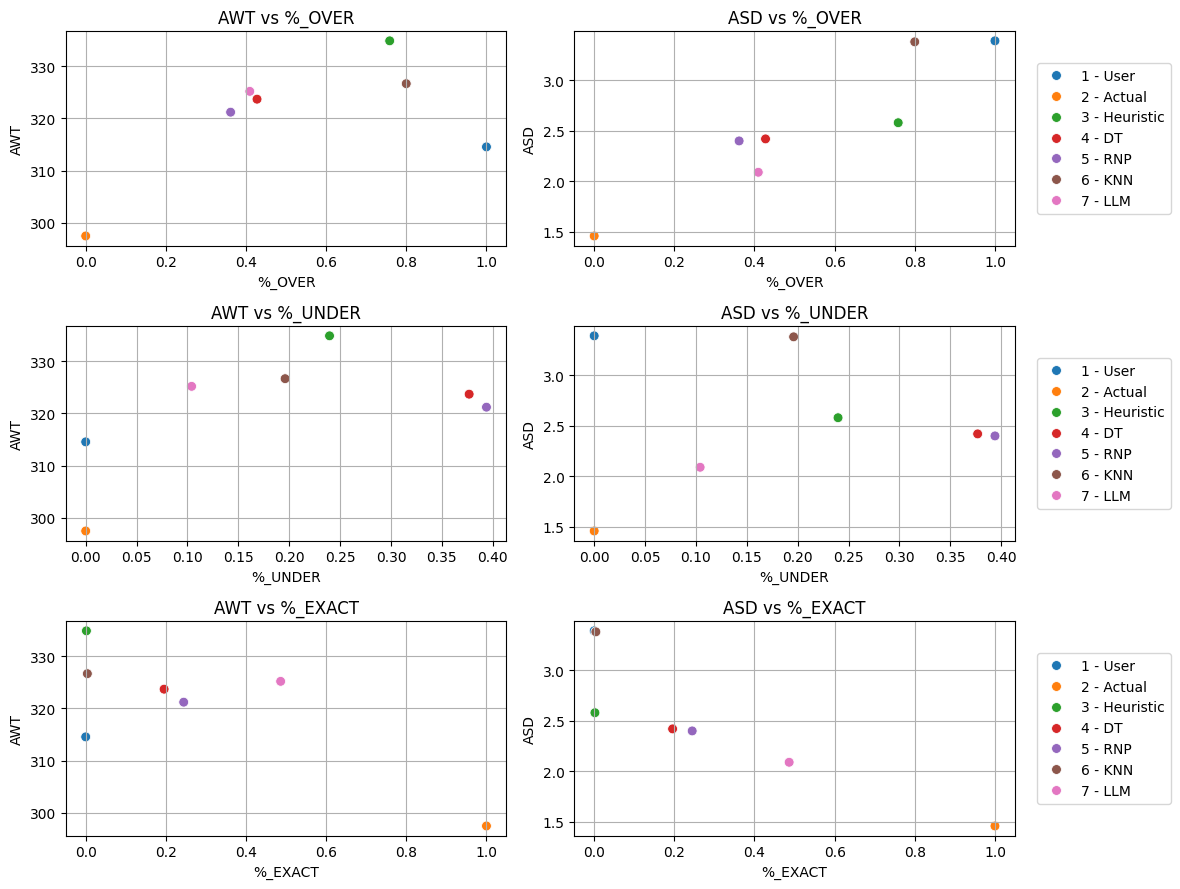

In [69]:
acc_metrics = ["%_OVER", "%_UNDER", "%_EXACT"]
# sched_metrics = ["AWT", "ASD", "ASU"]
sched_metrics = ["AWT", "ASD"]

accuracy_vs_metrics_grid(summary_df_sjf_avg, acc_metrics, sched_metrics, size=(12, 9))

### Rank–Rank Correlation

In [70]:
def rank_rank_correlation(summary_df, sched_metric, acc_metric, method_col="Estimation"):
    """
    summary_df: one row per estimation method (SJF only)
    """
    df = summary_df.copy()

    # Rank: lower scheduling metric is better, higher accuracy is better
    df["sched_rank"] = df[sched_metric].rank(ascending=True)
    df["acc_rank"] = df[acc_metric].rank(ascending=False)

    kendall = kendalltau(df["sched_rank"], df["acc_rank"])
    spearman = spearmanr(df["sched_rank"], df["acc_rank"])

    return {
        "kendall_tau": kendall.correlation,
        "spearman_r": spearman.correlation
    }

In [71]:
print("AWT vs MAE")
print(rank_rank_correlation(summary_df_sjf_avg, "AWT", "MAE"))
print("ASD vs MAE")
print(rank_rank_correlation(summary_df_sjf_avg, "ASD", "MAE"))
print("AWT vs MAPE")
print(rank_rank_correlation(summary_df_sjf_avg, "AWT", "MAPE"))
print("ASD vs MAPE")
print(rank_rank_correlation(summary_df_sjf_avg, "ASD", "MAPE"))
print("AWT vs EA")
print(rank_rank_correlation(summary_df_sjf_avg, "AWT", "EA"))
print("ASD vs EA")
print(rank_rank_correlation(summary_df_sjf_avg, "ASD", "EA"))
print("AWT vs TAU")
print(rank_rank_correlation(summary_df_sjf_avg, "AWT", "TAU"))
print("ASD vs TAU")
print(rank_rank_correlation(summary_df_sjf_avg, "ASD", "TAU"))

AWT vs MAE
{'kendall_tau': -0.04761904761904762, 'spearman_r': -0.07142857142857144}
ASD vs MAE
{'kendall_tau': -0.6190476190476191, 'spearman_r': -0.7500000000000002}
AWT vs MAPE
{'kendall_tau': -0.14285714285714288, 'spearman_r': -0.28571428571428575}
ASD vs MAPE
{'kendall_tau': -0.9047619047619049, 'spearman_r': -0.9642857142857145}
AWT vs EA
{'kendall_tau': 0.23809523809523814, 'spearman_r': 0.3214285714285715}
ASD vs EA
{'kendall_tau': 0.8095238095238096, 'spearman_r': 0.9285714285714288}
AWT vs TAU
{'kendall_tau': 0.14285714285714288, 'spearman_r': 0.28571428571428575}
ASD vs TAU
{'kendall_tau': 0.9047619047619049, 'spearman_r': 0.9642857142857145}


In [72]:
print("AWT vs MAE_OVER")
print(rank_rank_correlation(summary_df_sjf_avg, "AWT", "MAE_OVER"))
print("ASD vs MAE_OVER")
print(rank_rank_correlation(summary_df_sjf_avg, "ASD", "MAE_OVER"))
print("AWT vs MAE_UNDER")
print(rank_rank_correlation(summary_df_sjf_avg, "AWT", "MAE_UNDER"))
print("ASD vs MAE_UNDER")
print(rank_rank_correlation(summary_df_sjf_avg, "ASD", "MAE_UNDER"))

print("AWT vs MAE_A")
print(rank_rank_correlation(summary_df_sjf_avg, "AWT", "MAE_A"))
print("ASD vs MAE_A")
print(rank_rank_correlation(summary_df_sjf_avg, "ASD", "MAE_A"))
print("AWT vs MAE_B")
print(rank_rank_correlation(summary_df_sjf_avg, "AWT", "MAE_B"))
print("ASD vs MAE_B")
print(rank_rank_correlation(summary_df_sjf_avg, "ASD", "MAE_B"))
print("AWT vs MAE_C")
print(rank_rank_correlation(summary_df_sjf_avg, "AWT", "MAE_C"))
print("ASD vs MAE_C")
print(rank_rank_correlation(summary_df_sjf_avg, "ASD", "MAE_C"))
print("AWT vs MAE_D")
print(rank_rank_correlation(summary_df_sjf_avg, "AWT", "MAE_D"))
print("ASD vs MAE_D")
print(rank_rank_correlation(summary_df_sjf_avg, "ASD", "MAE_D"))

AWT vs MAE_OVER
{'kendall_tau': 0.23809523809523814, 'spearman_r': 0.14285714285714288}
ASD vs MAE_OVER
{'kendall_tau': -0.5238095238095238, 'spearman_r': -0.6785714285714287}
AWT vs MAE_UNDER
{'kendall_tau': -0.7807200583588265, 'spearman_r': -0.8829187134416479}
ASD vs MAE_UNDER
{'kendall_tau': -0.39036002917941326, 'spearman_r': -0.3243374865704013}
AWT vs MAE_A
{'kendall_tau': -0.04761904761904762, 'spearman_r': -0.14285714285714288}
ASD vs MAE_A
{'kendall_tau': -0.8095238095238096, 'spearman_r': -0.8928571428571429}
AWT vs MAE_B
{'kendall_tau': 0.14285714285714288, 'spearman_r': 0.10714285714285716}
ASD vs MAE_B
{'kendall_tau': -0.4285714285714286, 'spearman_r': -0.642857142857143}
AWT vs MAE_C
{'kendall_tau': 0.14285714285714288, 'spearman_r': 0.07142857142857144}
ASD vs MAE_C
{'kendall_tau': -0.6190476190476191, 'spearman_r': -0.7500000000000002}
AWT vs MAE_D
{'kendall_tau': 0.04761904761904762, 'spearman_r': 0.0}
ASD vs MAE_D
{'kendall_tau': -0.5238095238095238, 'spearman_r': -

In [73]:
print("AWT vs %_OVER")
print(rank_rank_correlation(summary_df_sjf_avg, "AWT", "%_OVER"))
print("ASD vs %_OVER")
print(rank_rank_correlation(summary_df_sjf_avg, "ASD", "%_OVER"))
print("AWT vs %_UNDER")
print(rank_rank_correlation(summary_df_sjf_avg, "AWT", "%_UNDER"))
print("ASD vs %_UNDER")
print(rank_rank_correlation(summary_df_sjf_avg, "ASD", "%_UNDER"))
print("AWT vs %_EXACT")
print(rank_rank_correlation(summary_df_sjf_avg, "AWT", "%_EXACT"))
print("ASD vs %_EXACT")
print(rank_rank_correlation(summary_df_sjf_avg, "ASD", "%_EXACT"))

AWT vs %_OVER
{'kendall_tau': -0.33333333333333337, 'spearman_r': -0.39285714285714296}
ASD vs %_OVER
{'kendall_tau': -0.9047619047619049, 'spearman_r': -0.9642857142857145}
AWT vs %_UNDER
{'kendall_tau': -0.29277002188455997, 'spearman_r': -0.41443123283995714}
ASD vs %_UNDER
{'kendall_tau': 0.09759000729485331, 'spearman_r': 0.0}
AWT vs %_EXACT
{'kendall_tau': 0.33333333333333337, 'spearman_r': 0.3571428571428572}
ASD vs %_EXACT
{'kendall_tau': 0.9047619047619049, 'spearman_r': 0.9642857142857145}


### Metrics Regression

#### Helpers

In [104]:
def plot_feature_importance(model, X, title):
    importances = model.feature_importances_
    indices = np.argsort(importances)

    plt.figure()
    plt.barh(range(len(indices)), importances[indices])
    plt.yticks(range(len(indices)), X.columns[indices])
    plt.xlabel("Importance")
    plt.title(title)
    plt.show()

def plot_combined_feature_importance(model1, model2, X, title1, title2, image_path=""):
    # Create a figure with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    
    models = [model1, model2]
    axes = [ax1, ax2]
    titles = [title1, title2]

    for model, ax, title in zip(models, axes, titles):
        importances = model.feature_importances_
        indices = np.argsort(importances)

        # Plot on the specific axis (ax) instead of plt
        ax.barh(range(len(indices)), importances[indices], color='skyblue', edgecolor='black')
        ax.set_yticks(range(len(indices)))
        ax.set_yticklabels(X.columns[indices])
        ax.set_xlabel("Importance")
        ax.set_title(title)

    plt.tight_layout()

    if image_path:
        plt.savefig(image_path, dpi=300)
        print(f"Grafico salvato in: {image_path}")
        
    plt.show()

In [75]:
def plot_permutation_importance(model, X, y, title):
    result = permutation_importance(
        model, X, y,
        n_repeats=30,
        random_state=42
    )

    sorted_idx = result.importances_mean.argsort()

    plt.figure()
    plt.barh(X.columns[sorted_idx], result.importances_mean[sorted_idx])
    plt.xlabel("Permutation Importance")
    plt.title(title)
    plt.show()

In [76]:
def plot_pdp(model, X, features, title, size=(12, 12)):
    fig, ax = plt.subplots(figsize=size)

    PartialDependenceDisplay.from_estimator(
        model,
        X,
        features,
        ax=ax
    )

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

In [77]:
def plot_loocv(y_true, y_pred, title, ylabel):
    plt.figure()
    plt.scatter(y_true, y_pred)
    plt.plot([y_true.min(), y_true.max()],
             [y_true.min(), y_true.max()])
    plt.xlabel("Actual")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()

In [78]:
def bootstrap_importance(X, y, n_runs=200):
    importances = []

    for _ in range(n_runs):
        idx = np.random.choice(len(X), len(X), replace=True)
        X_sample = X.iloc[idx]
        y_sample = y.iloc[idx]

        rf = RandomForestRegressor(n_estimators=200)
        rf.fit(X_sample, y_sample)

        importances.append(rf.feature_importances_)

    importances = np.array(importances)

    return importances.mean(axis=0), importances.std(axis=0)

def plot_importance(mean_imp, std_imp, feature_names, title):
    plt.figure()
    plt.barh(feature_names, mean_imp, xerr=std_imp)
    plt.xlabel("Importance")
    plt.title(title)
    plt.show()

In [79]:
def scatter_plot(df, x_col, y_col):
    plt.figure()
    plt.scatter(df[x_col], df[y_col])
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(f"{y_col} vs {x_col}")
    plt.show()

#### Random Forest - All Metrics

In [99]:
features = [
    "MAE", "MAPE", "EA", "TAU",
    "MAE_OVER", "MAE_UNDER",
    "%_OVER", "%_UNDER", "%_EXACT",
    "MAE_A", "MAE_B", "MAE_C", "MAE_D"
]

X = summary_df_sjf[features]

# --- targets
y_awt = summary_df_sjf["AWT"]
y_asd = summary_df_sjf["ASD"]

In [100]:
rf_awt = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

rf_asd = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

rf_awt.fit(X, y_awt)
rf_asd.fit(X, y_asd)

RandomForestRegressor(n_estimators=300, random_state=42)

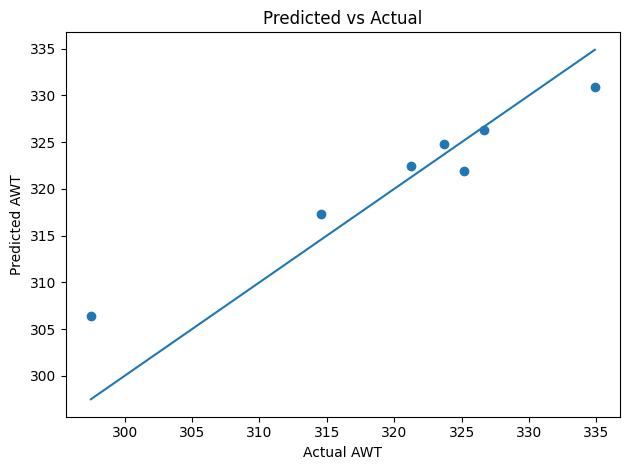

In [101]:
y_pred = rf_awt.predict(X)

plt.figure()
plt.scatter(y_awt, y_pred)
plt.xlabel("Actual AWT")
plt.ylabel("Predicted AWT")
plt.title("Predicted vs Actual")
plt.plot([y_awt.min(), y_awt.max()],
         [y_awt.min(), y_awt.max()])
plt.tight_layout()
plt.savefig("images/66000x980/awt_regression_sjf_M1.png", dpi=300)
plt.show()

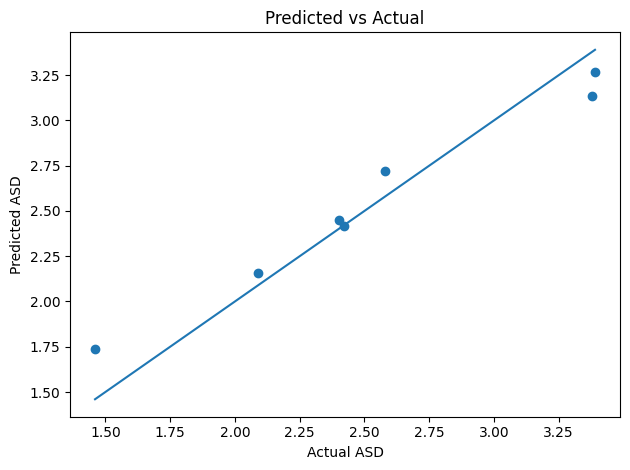

In [102]:
y_pred = rf_asd.predict(X)

plt.figure()
plt.scatter(y_asd, y_pred)
plt.xlabel("Actual ASD")
plt.ylabel("Predicted ASD")
plt.title("Predicted vs Actual")
plt.plot([y_asd.min(), y_asd.max()],
         [y_asd.min(), y_asd.max()])
plt.tight_layout()
plt.savefig("images/66000x980/asd_regression_sjf_M1.png", dpi=300)
plt.show()

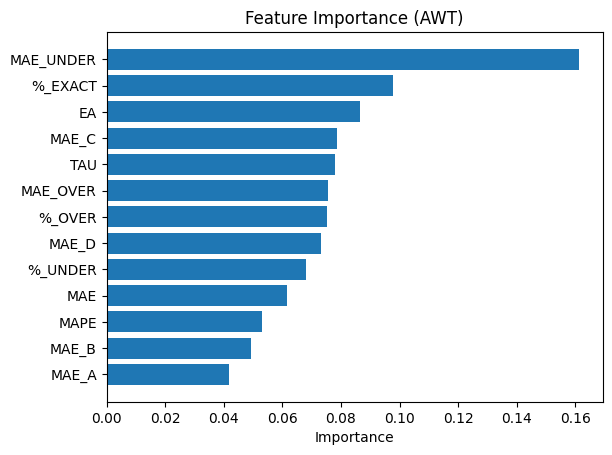

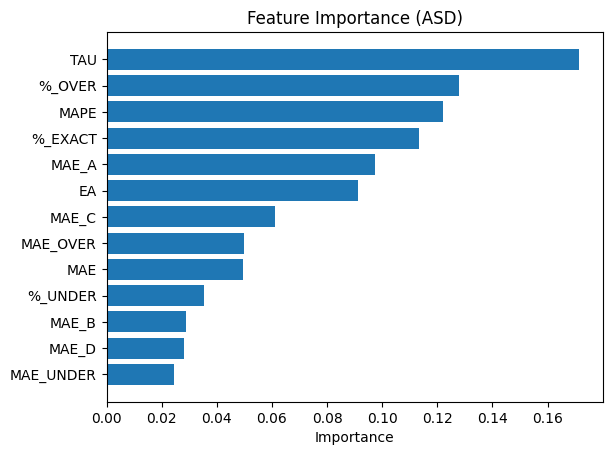

In [84]:
plot_feature_importance(rf_awt, X, "Feature Importance (AWT)")
plot_feature_importance(rf_asd, X, "Feature Importance (ASD)")

Grafico salvato in: images/66000x980/feature_importance_sjf_M1.png


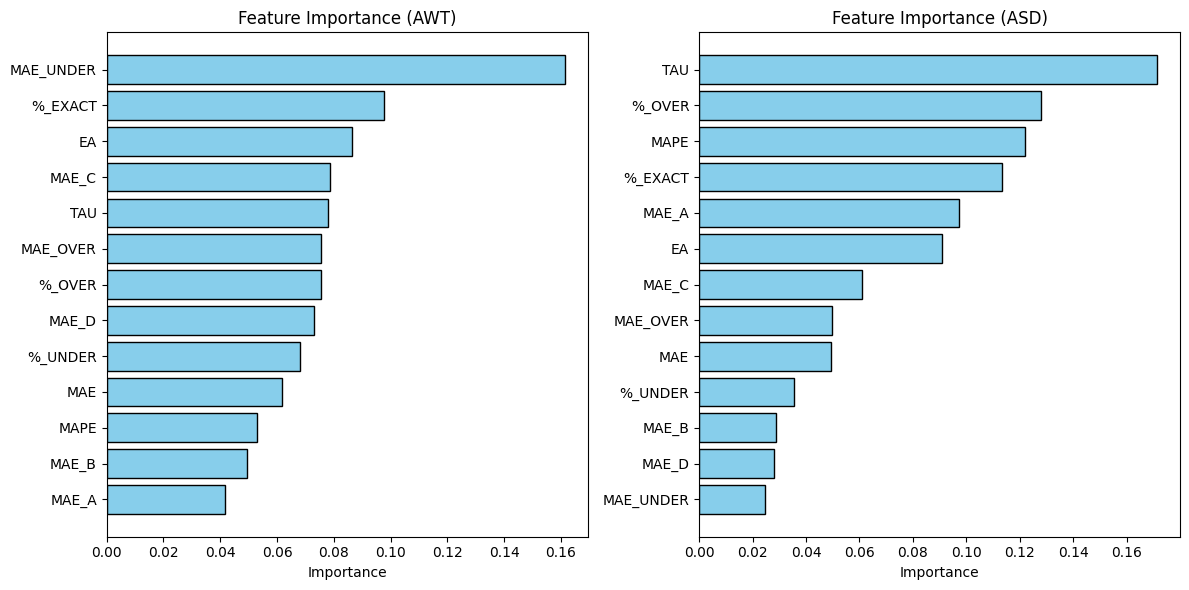

In [105]:
plot_combined_feature_importance(rf_awt, rf_asd, X, "Feature Importance (AWT)", "Feature Importance (ASD)", "images/66000x980/feature_importance_sjf_M1.png")

#### Random Forest - Reduced Metrics

In [85]:
features = [
    "MAE", "MAPE", "EA", "TAU",
    "MAE_OVER", "MAE_UNDER",
    "%_OVER", "%_UNDER", "%_EXACT"]

X = summary_df_sjf[features]

# --- targets
y_awt = summary_df_sjf["AWT"]
y_asd = summary_df_sjf["ASD"]

In [86]:
rf_awt = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

rf_asd = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    random_state=42
)

rf_awt.fit(X, y_awt)
rf_asd.fit(X, y_asd)

RandomForestRegressor(n_estimators=300, random_state=42)

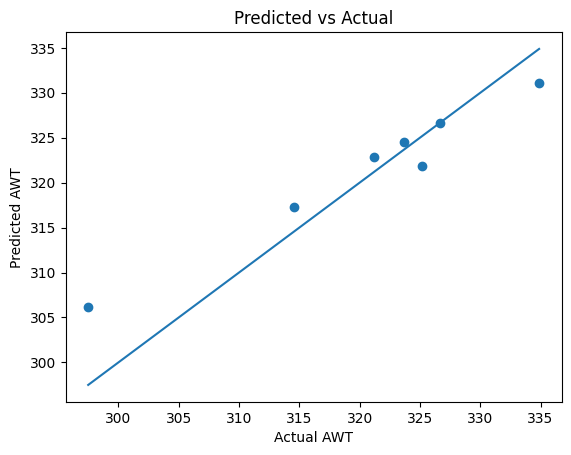

In [87]:
y_pred = rf_awt.predict(X)

plt.figure()
plt.scatter(y_awt, y_pred)
plt.xlabel("Actual AWT")
plt.ylabel("Predicted AWT")
plt.title("Predicted vs Actual")
plt.plot([y_awt.min(), y_awt.max()],
         [y_awt.min(), y_awt.max()])
plt.show()

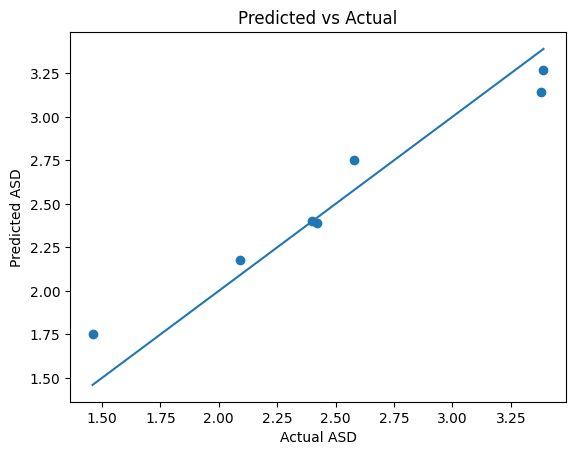

In [88]:
y_pred = rf_asd.predict(X)

plt.figure()
plt.scatter(y_asd, y_pred)
plt.xlabel("Actual ASD")
plt.ylabel("Predicted ASD")
plt.title("Predicted vs Actual")
plt.plot([y_asd.min(), y_asd.max()],
         [y_asd.min(), y_asd.max()])
plt.show()

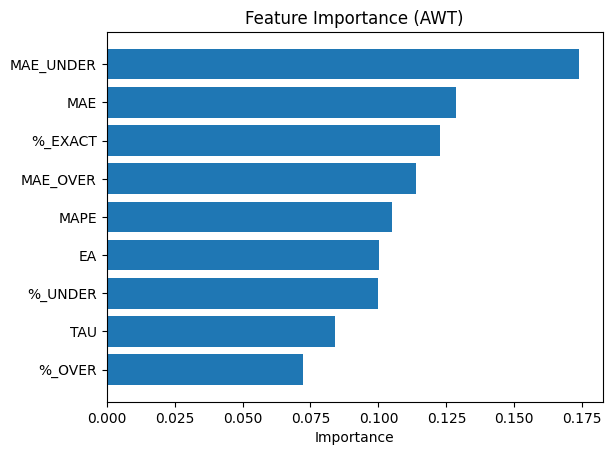

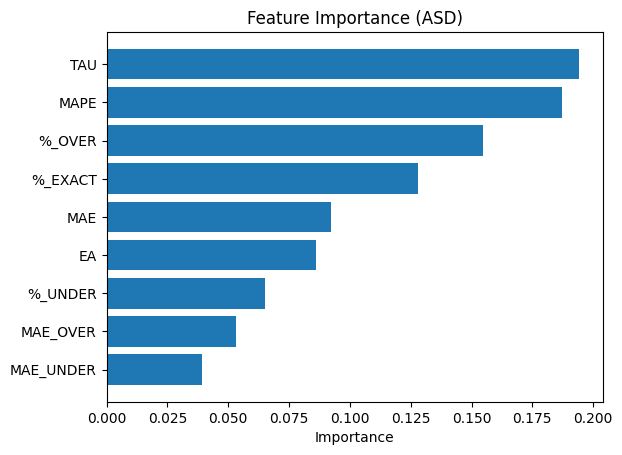

In [89]:
plot_feature_importance(rf_awt, X, "Feature Importance (AWT)")
plot_feature_importance(rf_asd, X, "Feature Importance (ASD)")

#### Random Forest + LOO-CV

In [90]:
features = [
    "MAE", "MAPE", "EA", "TAU",
    "MAE_OVER", "MAE_UNDER",
    "%_OVER", "%_UNDER", "%_EXACT",
    "MAE_A", "MAE_B", "MAE_C", "MAE_D"
]

X = summary_df_sjf[features]

y_awt = summary_df_sjf["AWT"]
y_asd = summary_df_sjf["ASD"]

In [91]:
loo = LeaveOneOut()

rf_awt = RandomForestRegressor(n_estimators=300, random_state=42)
rf_asd = RandomForestRegressor(n_estimators=300, random_state=42)

# --- LOOCV predictions
y_pred_awt = cross_val_predict(rf_awt, X, y_awt, cv=loo)
y_pred_asd = cross_val_predict(rf_asd, X, y_asd, cv=loo)

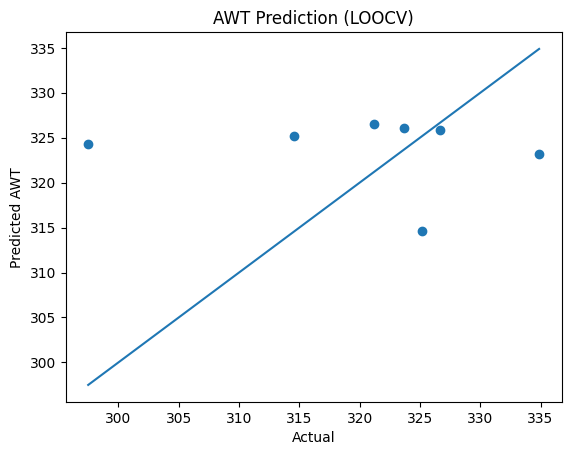

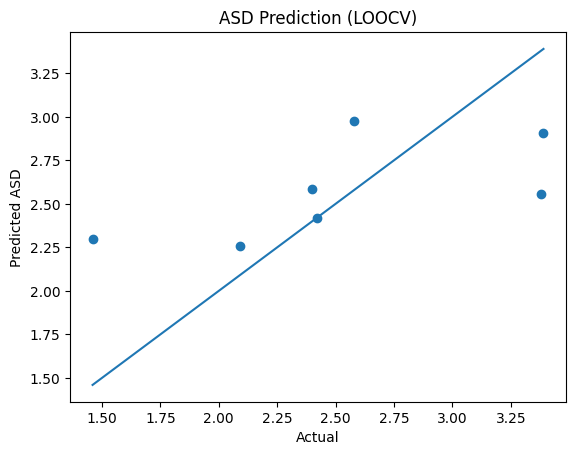

In [92]:
plot_loocv(y_awt, y_pred_awt, "AWT Prediction (LOOCV)", "Predicted AWT")
plot_loocv(y_asd, y_pred_asd, "ASD Prediction (LOOCV)", "Predicted ASD")

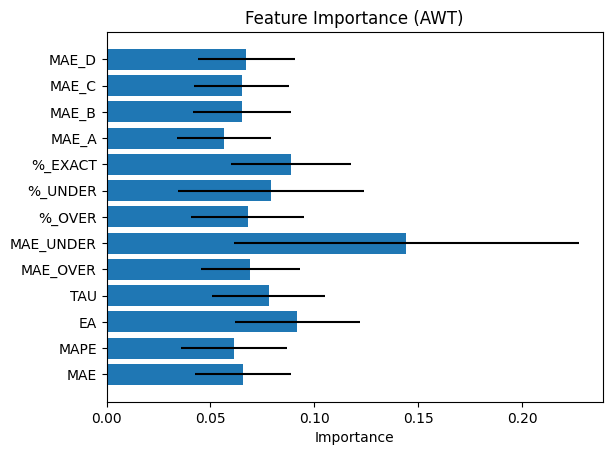

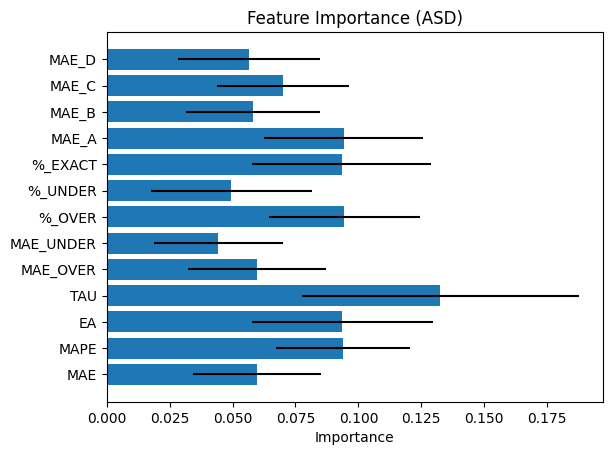

In [93]:
mean_awt, std_awt = bootstrap_importance(X, y_awt)
mean_asd, std_asd = bootstrap_importance(X, y_asd)

plot_importance(mean_awt, std_awt, X.columns, "Feature Importance (AWT)")
plot_importance(mean_asd, std_asd, X.columns, "Feature Importance (ASD)")